<a href="https://colab.research.google.com/github/amit-masel/nova-academy-course-cancellation/blob/main/nova_academy_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><br><font size=10>Final Project</font><br>
<font size=6>NOVA ACADEMY</font>
<center><img src="https://drive.google.com/uc?export=view&id=1GU784y8WCoKRQHkr5NMWOrTkLouSWRCD" width="300" height="auto"></center>

<b>Introduction to Machine Learning – Digital Sciences for High-Tech</b>
<br><b>Group 03</b> | Esti Binyaminov 212648372 | Amit Masel 209754951
<br><i>2026</i></center>

# 1. Business Understanding

**Nova Academy** is an international B2B company providing advanced technological training courses.
A large percentage of course orders are cancelled before the course begins (`Dropped_Course`), causing double losses:
wasted infrastructure costs and empty seats that prevent additional revenue.

**What's our Goal?** Build a machine learning model that receives new registration data and predicts the **probability** that an order will be cancelled.

**Success criterion:** AUC of at least **0.70** on a held-out test set.

**Methodology:** We follow the full **CRISP-DM** process:
1. Business Understanding (this section)
2. Data Understanding – EDA
3. Data Preparation – cleaning, imputation, feature engineering, encoding
4. Modeling – multiple models + stacking ensemble
5. Evaluation – AUC, confusion matrix, SHAP
6. Deployment – predictions on the unlabeled test set

# 2. Data Understanding

## 2.1 Imports & Global Plot Style

In [ ]:
import os, json, re

# Data & viz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Stats
import statsmodels.api as sm
from scipy.stats import chi2_contingency, mannwhitneyu
from scipy.stats import chi2 as chi2_dist          # renamed to avoid collision with chi2_contingency's output variable
from scipy.optimize import minimize
from statsmodels.stats.outliers_influence import variance_inflation_factor

# sklearn — preprocessing & model selection
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      RandomizedSearchCV, cross_val_score)
from sklearn.base import clone

# sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.mixture import GaussianMixture

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)

# Interpretation
import shap

# Misc
!pip install holidays -q
import holidays

# global plotting style (used across the whole notebook)
MAIN_COLOR = 'steelblue'
ACCENT_COLOR = 'seagreen'
WARN_COLOR = 'red'

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 2.2 Loading the Data

In [ ]:
raw_data = pd.read_csv("Train_Data.csv")
raw_data.head()  # reviewing the dataset

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,...,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63464 entries, 0 to 63463
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Client_ID                    63464 non-null  int64  
 1   Professionals_Count          63464 non-null  int64  
 2   Students_Count               63460 non-null  float64
 3   Observers_Count              63464 non-null  int64  
 4   Course_Start_Date            63464 non-null  object 
 5   Practical_Hours              63464 non-null  int64  
 6   Theory_Hours                 63464 non-null  int64  
 7   Registration_Days_Before     60798 non-null  float64
 8   Origin_Country               62907 non-null  object 
 9   Catering_Package             63057 non-null  object 
 10  Welcome_Gift_Type            63464 non-null  object 
 11  Requested_Lab_Config         61728 non-null  object 
 12  Assigned_Lab_Config          63464 non-null  object 
 13  Prev_Course_Drop

## 2.3 Text Standardization

Before any analysis we unify text formats: removing noise characters (`* ! # ?`), trimming whitespace, and turning missing values to Nan.

> **Note on leakage:** this step is *deterministic* – it does not learn any statistic from the data
> (no means, no encodings). Therefore it is safe to apply **before** the train/test split.

In [ ]:
def clean_text(val):
    if pd.isna(val):
        return np.nan
    s = str(val)
    s = re.sub(r'[*!#?]', '', s)
    s = s.strip()
    if s == '':
        return np.nan
    return s.lower()


categorical_cols = raw_data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col == 'Course_Start_Date':
        raw_data[col] = pd.to_datetime(raw_data[col], errors='coerce')
    else:
        raw_data[col] = raw_data[col].apply(clean_text)

# checking
raw_data.head()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,...,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,2015-07-01,0,2,257.0,prt,lunch included,...,general admission,blue,traditional it & telecomm,b2b platforms & resellers,0,219.0,NaN,pay upon start,101.5,0
1,78660,1,0.0,0,2015-07-01,0,2,257.0,prt,lunch included,...,general admission,blue,traditional it & telecomm,b2b platforms & resellers,0,219.0,NaN,pay upon start,80.0,0
2,51396,1,0.0,0,2015-07-01,0,2,257.0,prt,lunch included,...,general admission,red,traditional it & telecomm,b2b platforms & resellers,0,219.0,NaN,pay upon start,80.0,0
3,34000,2,0.0,0,2015-07-01,0,2,257.0,prt,lunch included,...,general admission,red,traditional it & telecomm,b2b platforms & resellers,0,219.0,NaN,pay upon start,101.5,0
4,69025,1,0.0,0,2015-07-01,0,2,257.0,prt,lunch included,...,general admission,orange,traditional it & telecomm,b2b platforms & resellers,0,219.0,NaN,pay upon start,80.0,0


In [ ]:
# number of unique values per categorical column (after cleaning)
cat_cols = ['Catering_Package', 'Welcome_Gift_Type', 'Requested_Lab_Config',
            'Assigned_Lab_Config', 'Enrollment_Type', 'Lanyard_Color',
            'Client_Category', 'Submission_Source', 'Payment_Terms', 'Origin_Country']

for col in cat_cols:
    print(f"{col}: {raw_data[col].nunique()} unique values")

Catering_Package: 4 unique values
Welcome_Gift_Type: 4 unique values
Requested_Lab_Config: 8 unique values
Assigned_Lab_Config: 9 unique values
Enrollment_Type: 4 unique values
Lanyard_Color: 5 unique values
Client_Category: 8 unique values
Submission_Source: 5 unique values
Payment_Terms: 4 unique values
Origin_Country: 154 unique values


## 2.4 Train / Test Split — performed EARLY to prevent data leakage

We split the data **before** any statistic-based processing.
From this point on:
- **EDA** is performed on the **training set only**.
- Every learned parameter (imputation medians, target encodings) is computed on the **training set only** and then applied to the test set.

`stratify=y` keeps the same cancellation ratio in both sets.

In [ ]:
train_df, test_df = train_test_split(
    raw_data,
    test_size=0.2,
    random_state=42,
    stratify=raw_data['Dropped_Course']
)

train_df = train_df.copy()
test_df = test_df.copy()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")
print(f"Drop rate in train: {train_df['Dropped_Course'].mean():.3f}")
print(f"Drop rate in test:  {test_df['Dropped_Course'].mean():.3f}")

train_df: (50771, 29)
test_df:  (12693, 29)
Drop rate in train: 0.414
Drop rate in test:  0.414


## 2.5 Exploratory Data Analysis (training set only)

### 2.5.1 Summary Statistics

In [ ]:
train_df.describe()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost,Dropped_Course
count,50771.000000,50771.000000,50767.000000,50771.000000,50771,50771.000000,50771.000000,48645.000000,50771.000000,50771.000000,50771.000000,49952.000000,50771.000000,50771.000000,50771.000000,41843.000000,2476.000000,50706.000000,50771.000000
mean,39750.063855,1.833704,8.553824,0.005456,2016-06-23 14:12:50.187705600,6.785941,2.165725,103.203721,0.095606,0.123023,0.513246,0.026445,4.003526,0.179965,0.026748,197.662381,5118.024637,98.872264,0.414390
min,1.000000,0.000000,0.000000,0.000000,2015-07-01 00:00:00,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,5003.000000,0.000000,0.000000
25%,19947.500000,2.000000,0.000000,0.000000,2016-02-13 00:00:00,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000,0.000000
50%,39783.000000,2.000000,0.000000,0.000000,2016-07-02 00:00:00,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5142.000000,94.500000,0.000000
75%,59573.000000,2.000000,0.000000,0.000000,2016-11-11 00:00:00,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000,1.000000
max,79330.000000,4.000000,9999.000000,10.000000,2017-04-26 00:00:00,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,322.000000,5206.000000,5400.000000,1.000000
std,22881.558843,0.507865,290.882083,0.094093,NaN,220.691243,1.470058,109.548377,0.436784,1.547270,0.764046,0.160956,23.206229,0.586646,0.161346,47.283238,70.391142,43.109057,0.492621


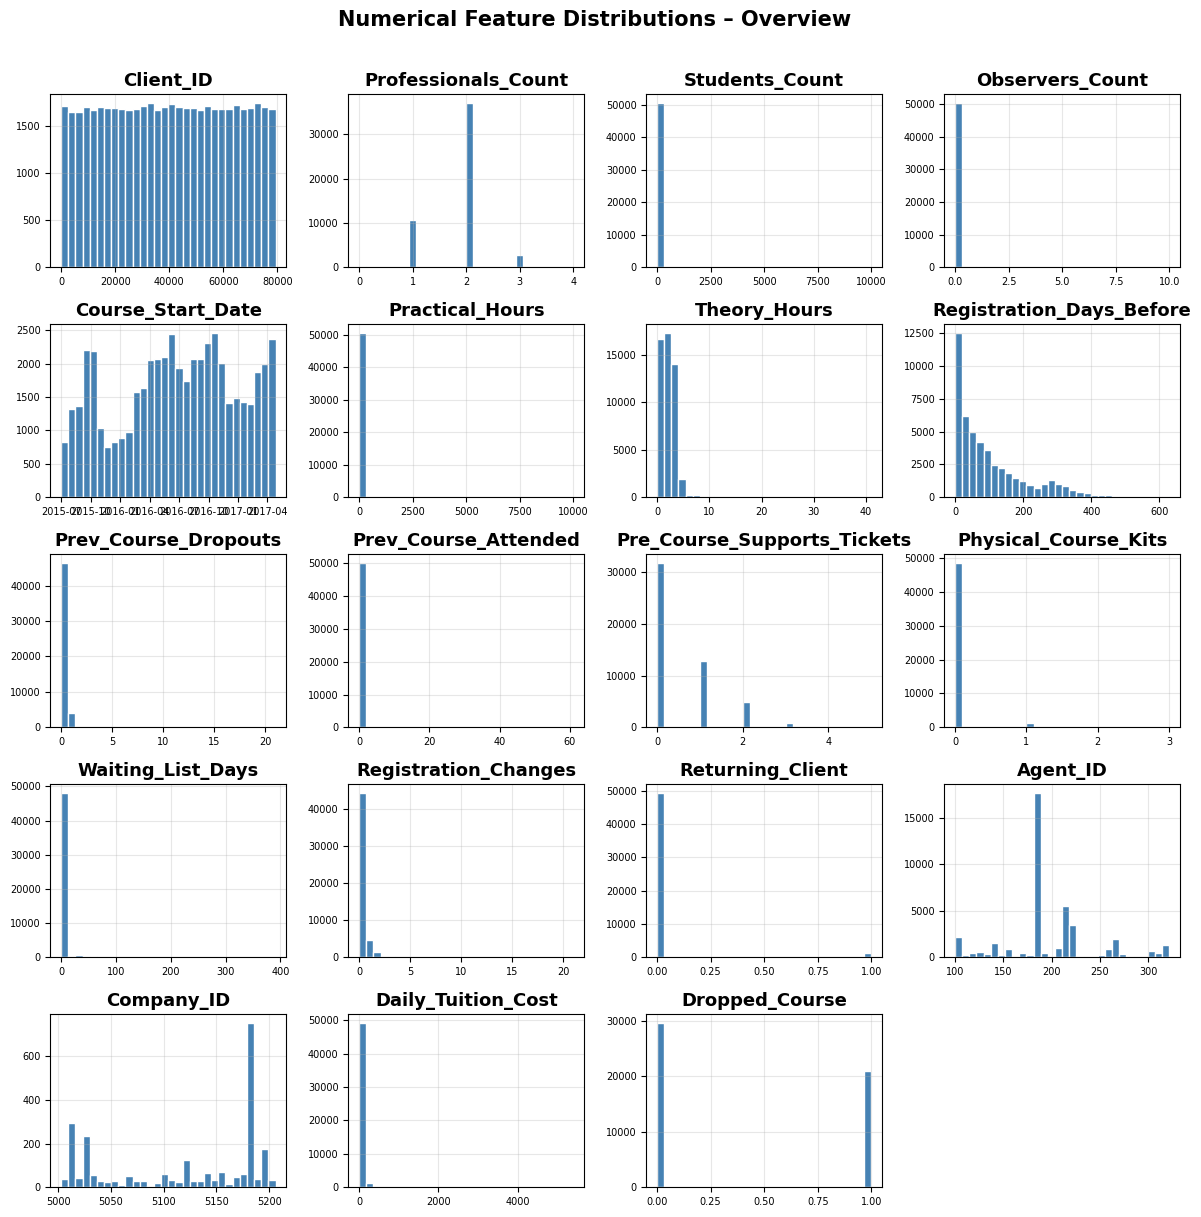

In [ ]:
# overview of all numerical distributions
axes = train_df.hist(figsize=(12, 12), bins=30, color=MAIN_COLOR, edgecolor='white',
                     xlabelsize=7, ylabelsize=7)
plt.suptitle('Numerical Feature Distributions – Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5.2 Outlier Analysis – per numerical feature

For each numerical feature we plot a histogram and a boxplot side by side,
with the key statistics printed below. Decisions on outlier removal are made in **Section 3.1**,
based on these visualizations.

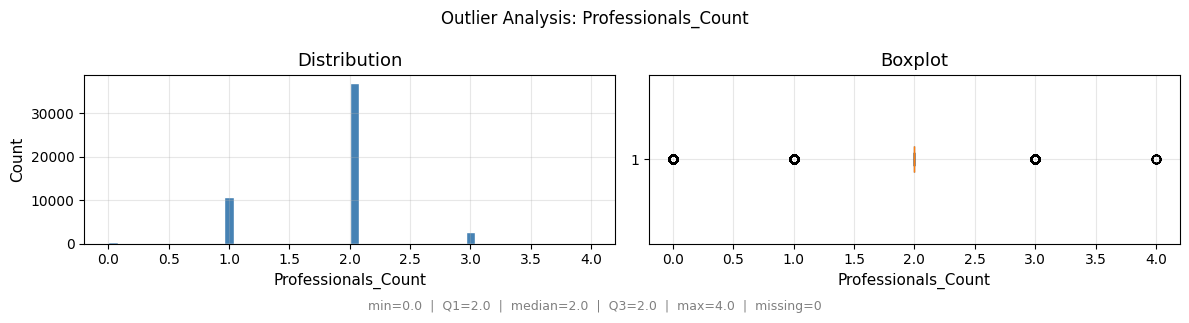

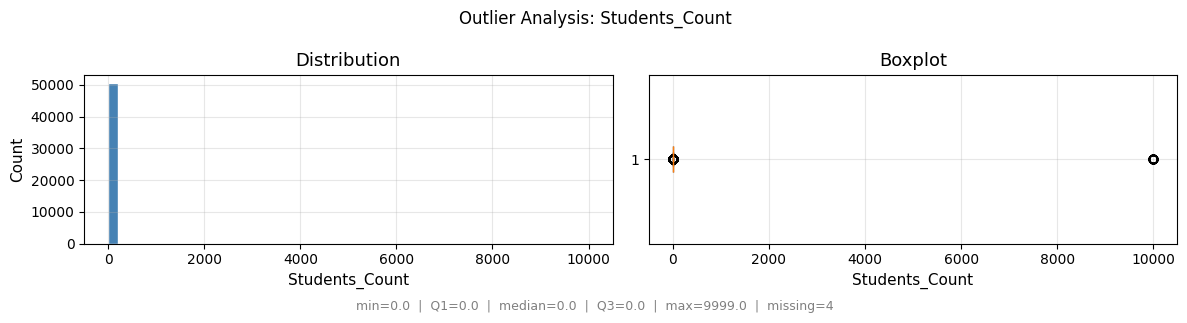

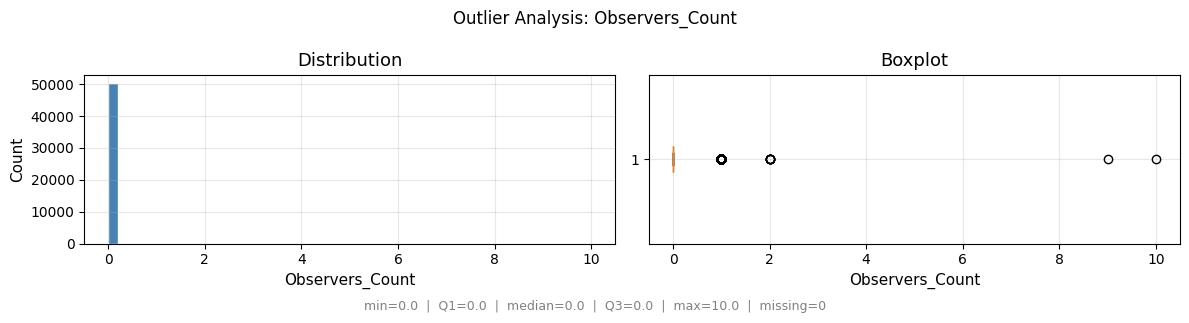

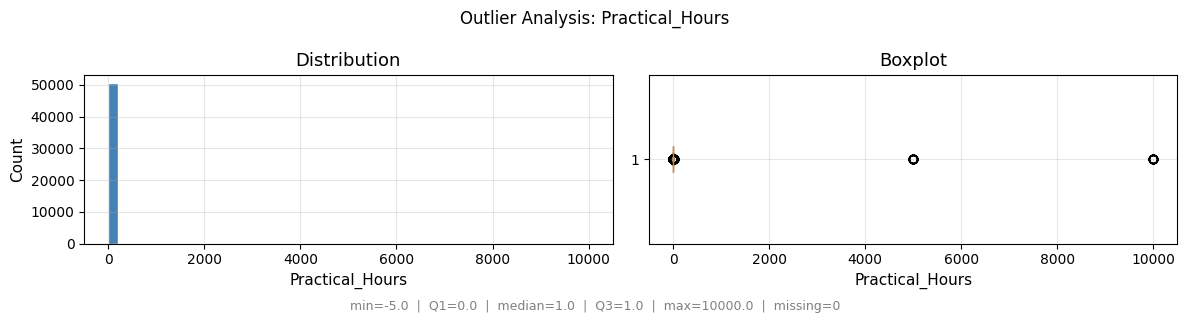

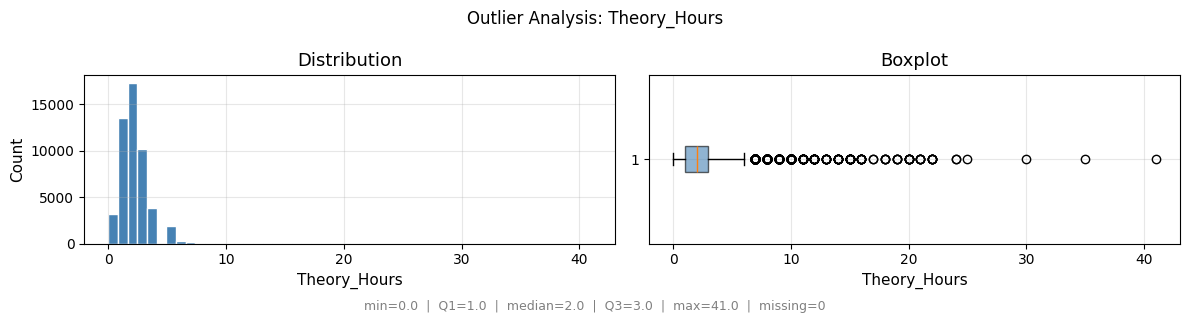

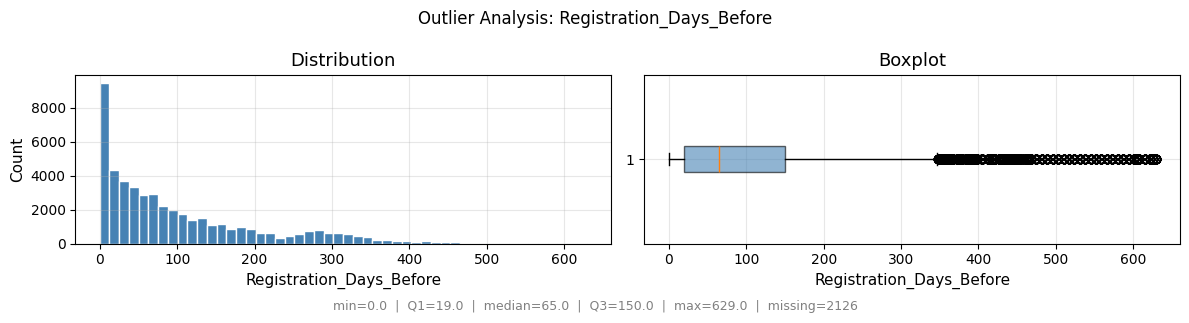

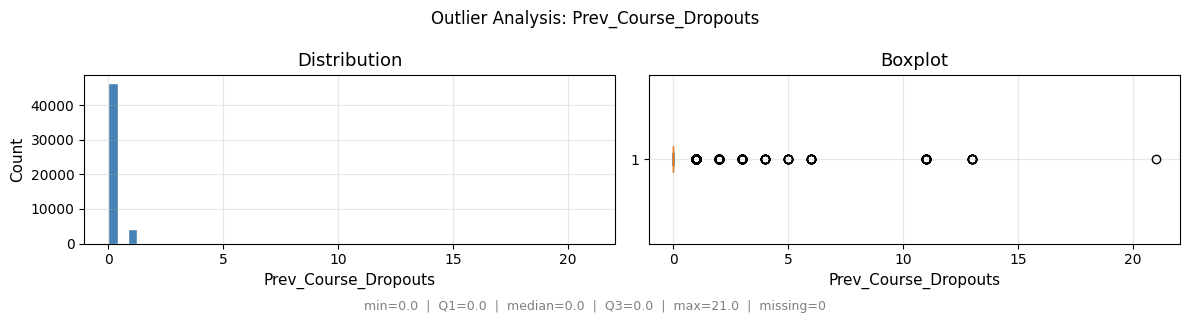

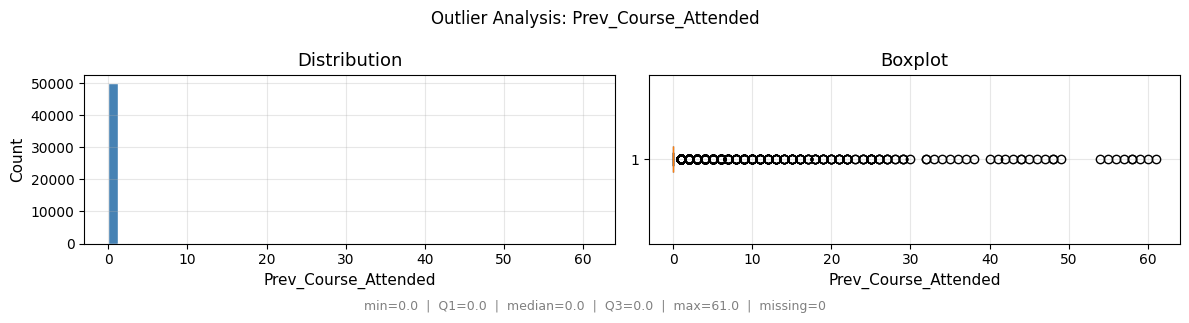

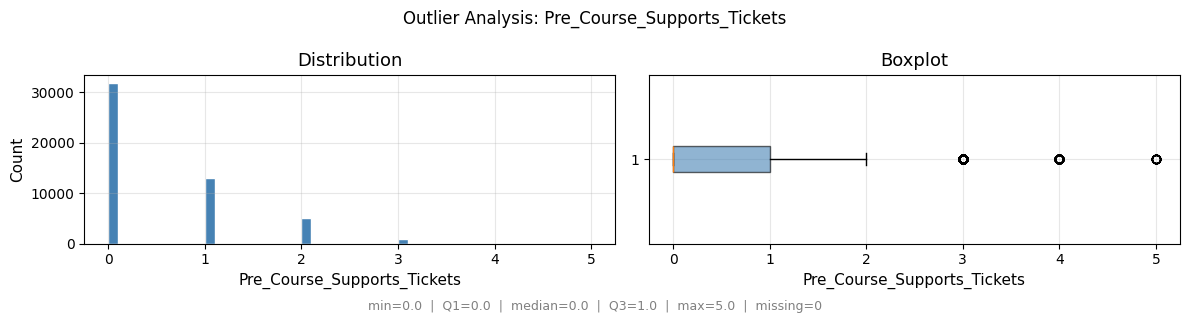

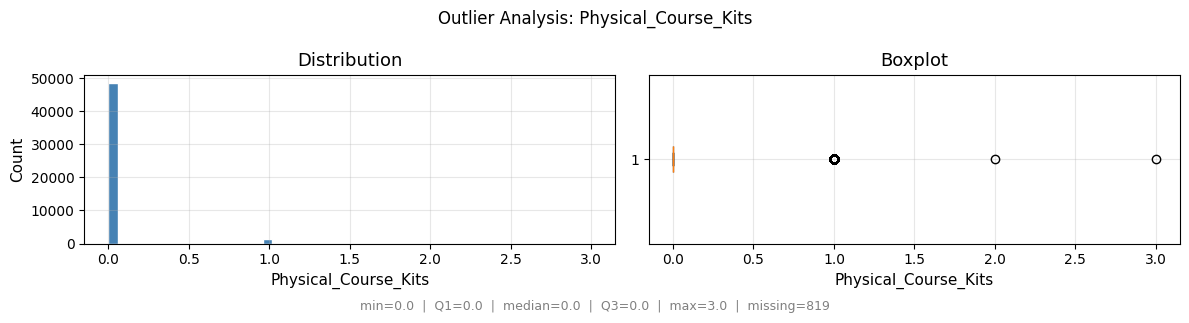

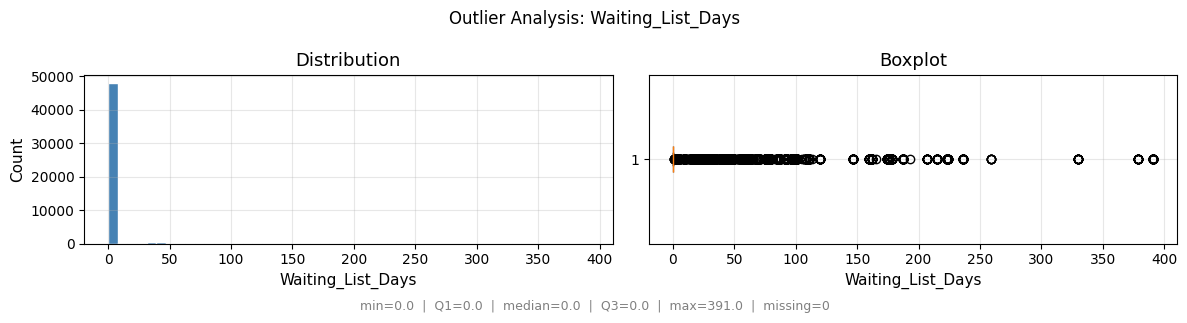

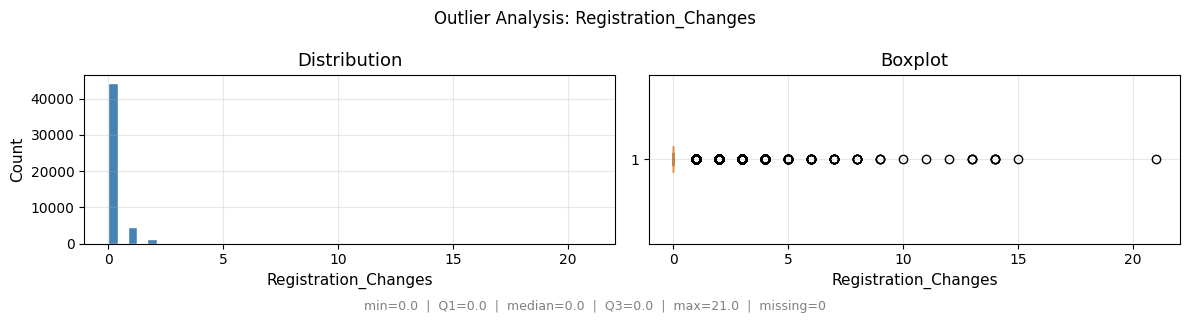

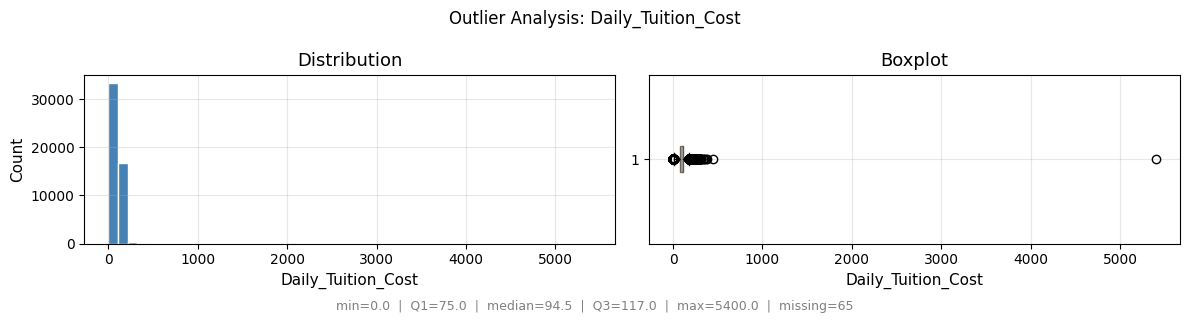

In [ ]:
numerical_cols_to_check = [
    'Professionals_Count', 'Students_Count', 'Observers_Count',
    'Practical_Hours', 'Theory_Hours', 'Registration_Days_Before',
    'Prev_Course_Dropouts', 'Prev_Course_Attended',
    'Pre_Course_Supports_Tickets', 'Physical_Course_Kits',
    'Waiting_List_Days', 'Registration_Changes', 'Daily_Tuition_Cost'
]

for col in numerical_cols_to_check:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(f'Outlier Analysis: {col}')

    axes[0].hist(train_df[col].dropna(), bins=50, color=MAIN_COLOR, edgecolor='white')
    axes[0].set_title('Distribution', fontweight='normal')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    axes[1].boxplot(train_df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor=MAIN_COLOR, alpha=0.6))
    axes[1].set_title('Boxplot', fontweight='normal')
    axes[1].set_xlabel(col)

    stats = train_df[col].describe()
    stats_text = (f"min={stats['min']:.1f}  |  Q1={stats['25%']:.1f}  |  "
                  f"median={stats['50%']:.1f}  |  Q3={stats['75%']:.1f}  |  "
                  f"max={stats['max']:.1f}  |  missing={train_df[col].isna().sum()}")
    fig.text(0.5, -0.02, stats_text, ha='center', fontsize=9, color='gray')

    plt.tight_layout()
    plt.show()

### 2.5.3 Zero Concentration per Column

Several features contain a high percentage of zeros. A zero could be a *meaningful* value
(e.g. `Prev_Course_Dropouts = 0` means the group never cancelled before), so these columns are kept.
Sparse columns are good candidates for binary indicator features in the Feature Engineering stage.

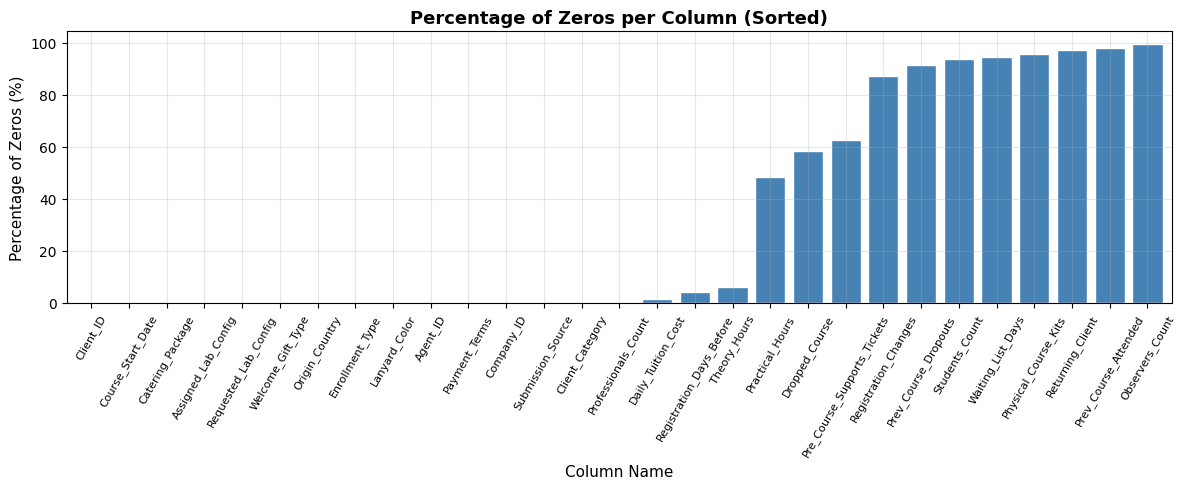

In [ ]:
zeros_pct = (train_df == 0).mean() * 100
zeros_sorted = zeros_pct.to_frame(name="zeros_percentage").sort_values("zeros_percentage", ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
zeros_sorted["zeros_percentage"].plot(kind='bar', color=MAIN_COLOR, width=0.8, ax=ax, edgecolor='white')
ax.set_title('Percentage of Zeros per Column (Sorted)')
ax.set_xlabel('Column Name')
ax.set_ylabel('Percentage of Zeros (%)')
plt.xticks(rotation=60, fontsize=8)
plt.tight_layout()
plt.show()

**Deep Dive: Which zero-heavy features are actually meaningful?**

As noted above, a zero in these columns is usually a real, meaningful state (no prior dropouts,
no waiting list, no support tickets) rather than a missing value — but "meaningful in principle"
is not the same as "predictive in practice". Before deciding what to do with each one, we test it
directly against the target.

For every feature with **more than 60% zeros**, we ask two separate statistical questions:
1. **Existence** — is "zero" vs. "non-zero" itself associated with `Dropped_Course`?
   (chi-square test on the 2×2 contingency table)
2. **Magnitude** — among the non-zero rows only, does the *size* of the value differ between clients
   who dropped and clients who didn't? (Mann–Whitney U test — these counts are highly skewed, not
   normally distributed, so a t-test would not be appropriate)

The columns crossing the 60% threshold (without already binary features): `Registration_Changes`, `Prev_Course_Dropouts`,
`Students_Count`, `Waiting_List_Days`, `Physical_Course_Kits`,
`Prev_Course_Attended`, `Observers_Count`. We also include `Pre_Course_Supports_Tickets`.

In [ ]:
zero_heavy_cols = [
    'Registration_Changes', 'Prev_Course_Dropouts', 'Students_Count',
    'Waiting_List_Days', 'Physical_Course_Kits',
    'Prev_Course_Attended', 'Observers_Count',
    'Pre_Course_Supports_Tickets',
]

rows = []
for col in zero_heavy_cols:
    is_zero = (train_df[col] == 0)
    pct_zero = is_zero.mean() * 100

    # Existence: is zero vs. non-zero associated with the target?
    contingency = pd.crosstab(is_zero, train_df['Dropped_Course'])
    chi2, p_existence, _, _ = chi2_contingency(contingency)
    drop_rate_zero    = train_df.loc[is_zero, 'Dropped_Course'].mean()
    drop_rate_nonzero = train_df.loc[~is_zero, 'Dropped_Course'].mean()

    # Magnitude: among non-zero rows, does the value differ by outcome?
    nz = train_df.loc[~is_zero]
    if nz[col].nunique() > 1:
        _, p_magnitude = mannwhitneyu(
            nz.loc[nz['Dropped_Course'] == 1, col],
            nz.loc[nz['Dropped_Course'] == 0, col],
            alternative='two-sided'
        )
    else:
        p_magnitude = np.nan  # non-zero values are (almost) constant, magnitude test not meaningful

    rows.append({
        'feature': col,
        'pct_zero': round(pct_zero, 1),
        'n_nonzero': int((~is_zero).sum()),
        'drop_rate_zero': round(drop_rate_zero, 3),
        'drop_rate_nonzero': round(drop_rate_nonzero, 3),
        'p_existence': p_existence,
        'p_magnitude': p_magnitude,
    })

decision_table = pd.DataFrame(rows).sort_values('pct_zero')
decision_table

,feature,pct_zero,n_nonzero,drop_rate_zero,drop_rate_nonzero,p_existence,p_magnitude
7,Pre_Course_Supports_Tickets,62.8,18898,0.544,0.197,0.000000e+00,6.826699e-01
0,Registration_Changes,87.4,6393,0.451,0.162,0.000000e+00,7.612237e-14
1,Prev_Course_Dropouts,91.6,4244,0.366,0.949,0.000000e+00,0.000000e+00
2,Students_Count,93.9,3077,0.419,0.348,2.027781e-14,NaN
3,Waiting_List_Days,94.7,2705,0.400,0.674,2.919448e-174,3.337768e-29
4,Physical_Course_Kits,95.8,2137,0.426,0.146,2.764380e-146,NaN
5,Prev_Course_Attended,98.0,1014,0.421,0.076,6.464993e-108,6.849648e-02
6,Observers_Count,99.5,254,0.416,0.154,4.604083e-17,2.233660e-01


**Conclusions:**

1. **None of these columns should be dropped.** Every zero-heavy column here
   shows a statistically significant gap between zero and non-zero rows — even `Observers_Count`,
   with only 254 non-zero rows (p ≈ 4.6e-17).
2. For three features — `Prev_Course_Attended`, `Observers_Count`, and `Pre_Course_Supports_Tickets`
   — only the *existence* test is significant; the magnitude test among non-zero rows is not
   (p = 0.069, 0.223, 0.683 respectively). For these, only "did this happen at all" matters, not
   "how many" — good candidates for an explicit `Has_X` binary indicator in Section 3


### 2.5.4 Correlation Analysis (numerical features)

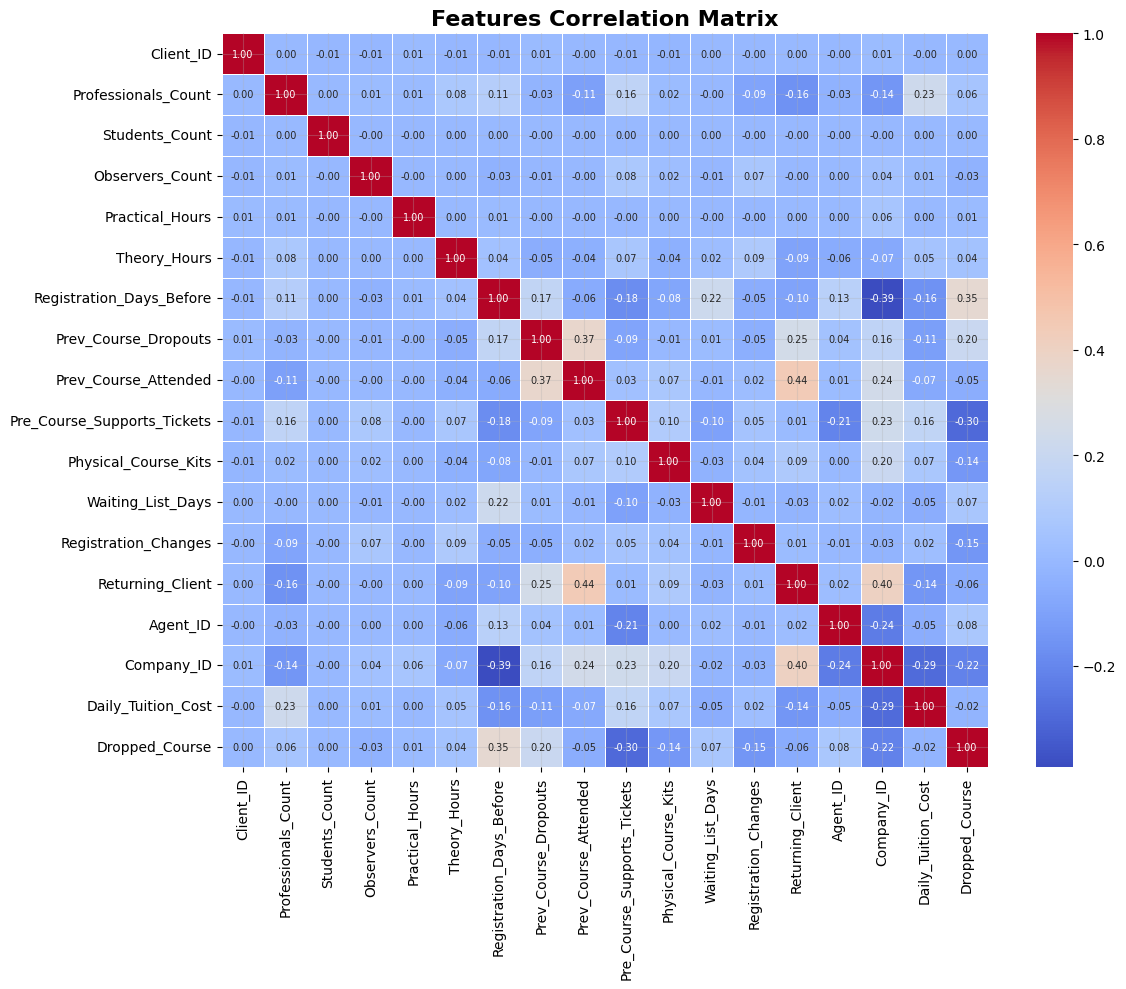

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
numerical_cols = train_df.select_dtypes(include=['number'])
corr_matrix = numerical_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title("Features Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

**Multicollinearity Check: Variance Inflation Factor (VIF)**

The correlation matrix above shows some non-trivial pairwise correlations among the numeric
features — most notably `Prev_Course_Attended` vs. `Returning_Client` (0.44) and
`Prev_Course_Dropouts` vs. `Prev_Course_Attended` (0.37). A single pairwise correlation, however,
doesn't tell us whether a feature is *redundant given all the others combined* — that is what
Variance Inflation Factor (VIF) measures.

For each feature, VIF regresses it on all the other numeric features and computes
`VIF = 1 / (1 - R²)`. A VIF of 1 means no linear relationship with the rest; common thresholds
for concern are VIF > 5 (moderate) or VIF > 10 (severe). This matters mainly for
`LogisticRegression` — tree-based models (XGBoost / LightGBM / RandomForest) are not sensitive
to collinearity between predictors.

We compute VIF on the continuous/count numeric features only — `Client_ID`, `Agent_ID`, and
`Company_ID` are excluded because they are arbitrary identifiers, not meaningful continuous
scales, so a VIF on them would not be interpretable.

In [ ]:
vif_cols = [
    'Professionals_Count', 'Students_Count', 'Observers_Count',
    'Practical_Hours', 'Theory_Hours', 'Registration_Days_Before',
    'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets',
    'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes',
    'Returning_Client', 'Daily_Tuition_Cost'
]

X_vif = train_df[vif_cols].fillna(train_df[vif_cols].median())
X_vif_const = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    'feature': X_vif_const.columns,
    'VIF': [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})
vif_table = vif_table[vif_table['feature'] != 'const'].sort_values('VIF', ascending=False)
vif_table

,feature,VIF
8,Prev_Course_Attended,1.386146
13,Returning_Client,1.316691
7,Prev_Course_Dropouts,1.237537
6,Registration_Days_Before,1.180761
1,Professionals_Count,1.140648
14,Daily_Tuition_Cost,1.130666
9,Pre_Course_Supports_Tickets,1.108165
11,Waiting_List_Days,1.054580
12,Registration_Changes,1.031773
5,Theory_Hours,1.031663


**Conclusions:**

1. **No multicollinearity concern.** The highest VIF is 1.39 (`Prev_Course_Attended`), followed
   by 1.32 (`Returning_Client`) and 1.24 (`Prev_Course_Dropouts`) — all far below even the
   conservative VIF > 5 threshold.
2. The 0.44 pairwise correlation seen in the heatmap is real but not problematic: once every
   *other* feature is accounted for, each one still carries mostly independent information.

### 2.5.5 Categorical Features vs. Target — Drop Rate per Category

Pearson correlation is undefined for categorical features, so instead we compute the **drop rate per category**:
for each value of the feature, the mean of `Dropped_Course` among orders holding that value.
The red dashed line is the overall average drop rate — bars far above/below it indicate a predictive feature.

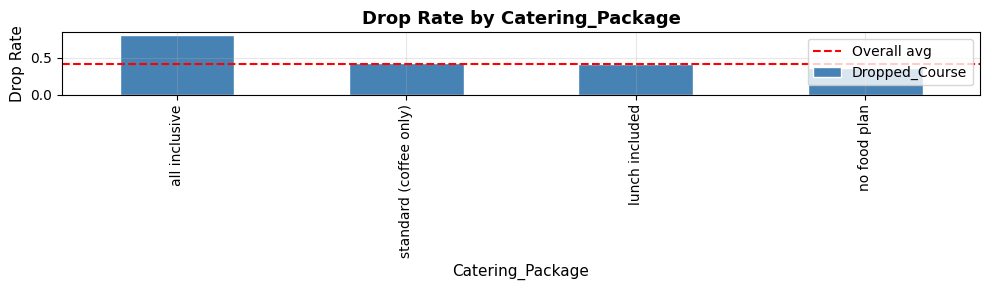

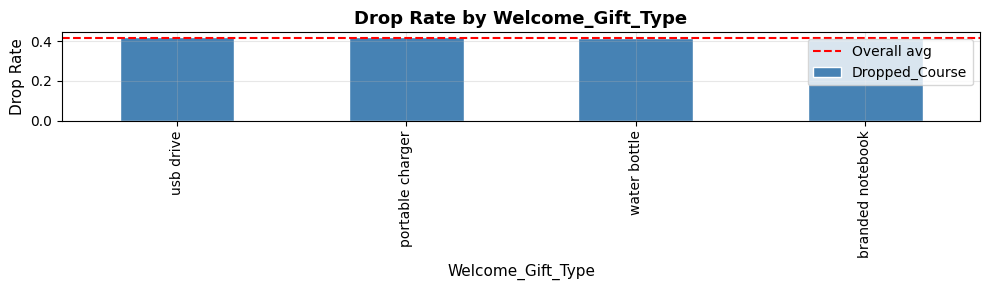

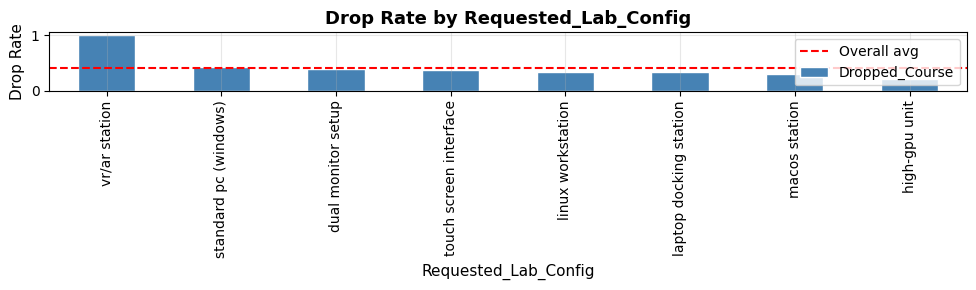

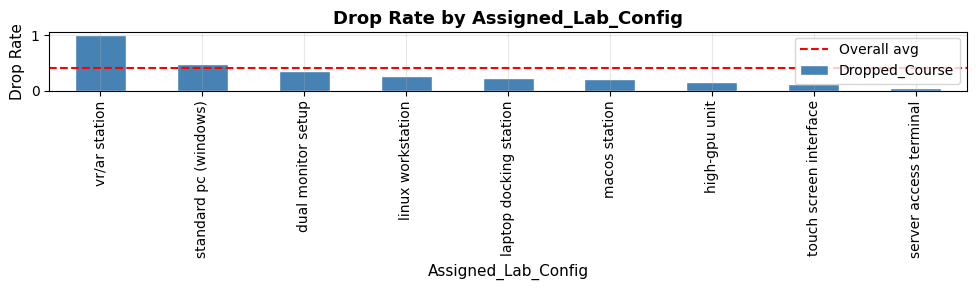

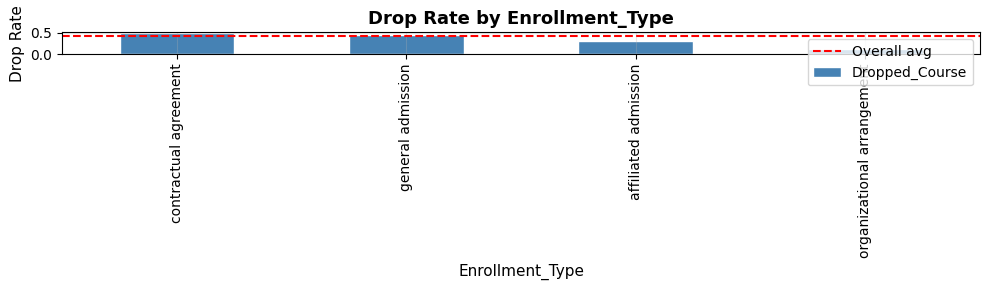

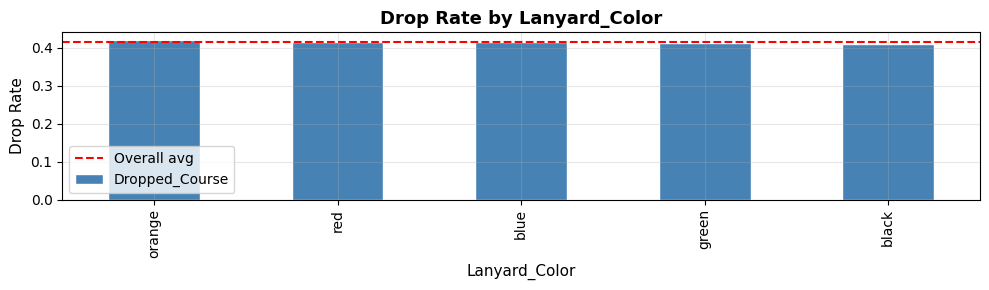

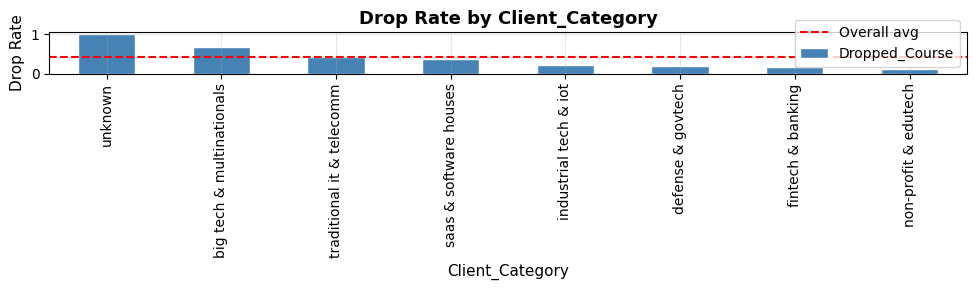

/tmp/ipykernel_1272/4202909901.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


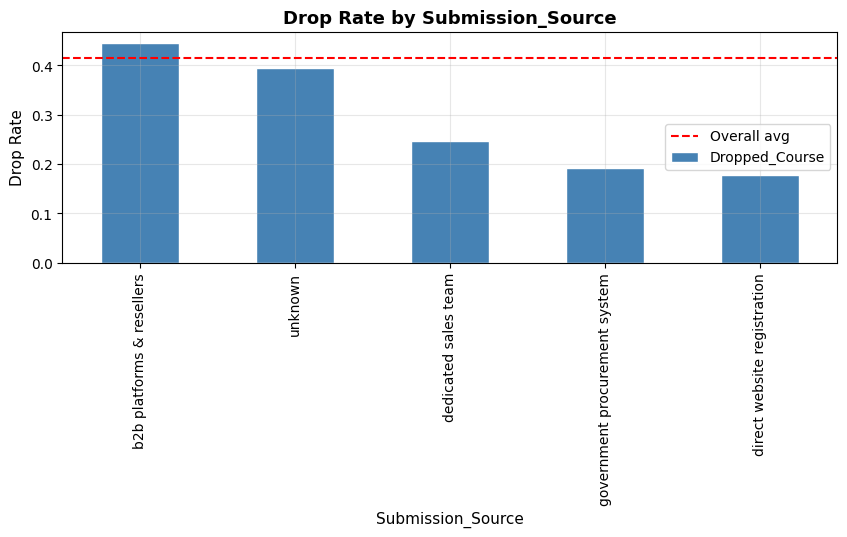

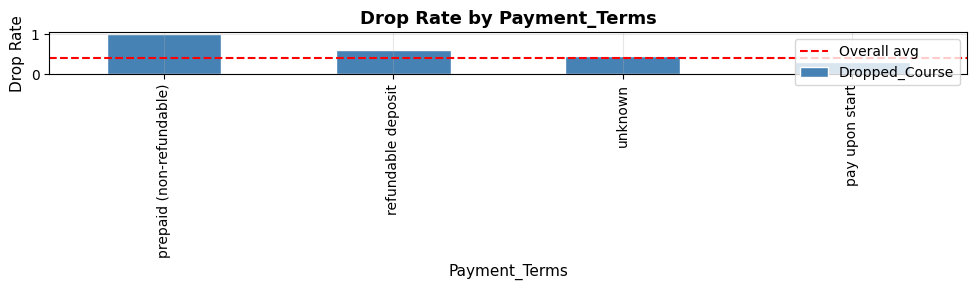

In [ ]:
cat_cols = ['Catering_Package', 'Welcome_Gift_Type', 'Requested_Lab_Config',
            'Assigned_Lab_Config', 'Enrollment_Type', 'Lanyard_Color',
            'Client_Category', 'Submission_Source', 'Payment_Terms']

for col in cat_cols:
    drop_rate = train_df.groupby(col)['Dropped_Course'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 3))
    drop_rate.plot(kind='bar', ax=ax, color=MAIN_COLOR, edgecolor='white')
    ax.set_title(f'Drop Rate by {col}')
    ax.set_ylabel('Drop Rate')
    ax.set_xlabel(col)
    ax.axhline(train_df['Dropped_Course'].mean(), color=WARN_COLOR, linestyle='--', label='Overall avg')
    ax.legend()
    plt.tight_layout()
    plt.show()

**Conclusions:**

1. **Two features carry no signal and are dropped as noise:** `Lanyard_Color` and
   `Welcome_Gift_Type` show drop rates essentially identical to the overall average across
   *every* category, with no meaningful spread. These are removed before modeling.

### 2.5.6 Missing Values Analysis

<Figure size 1000x600 with 0 Axes>

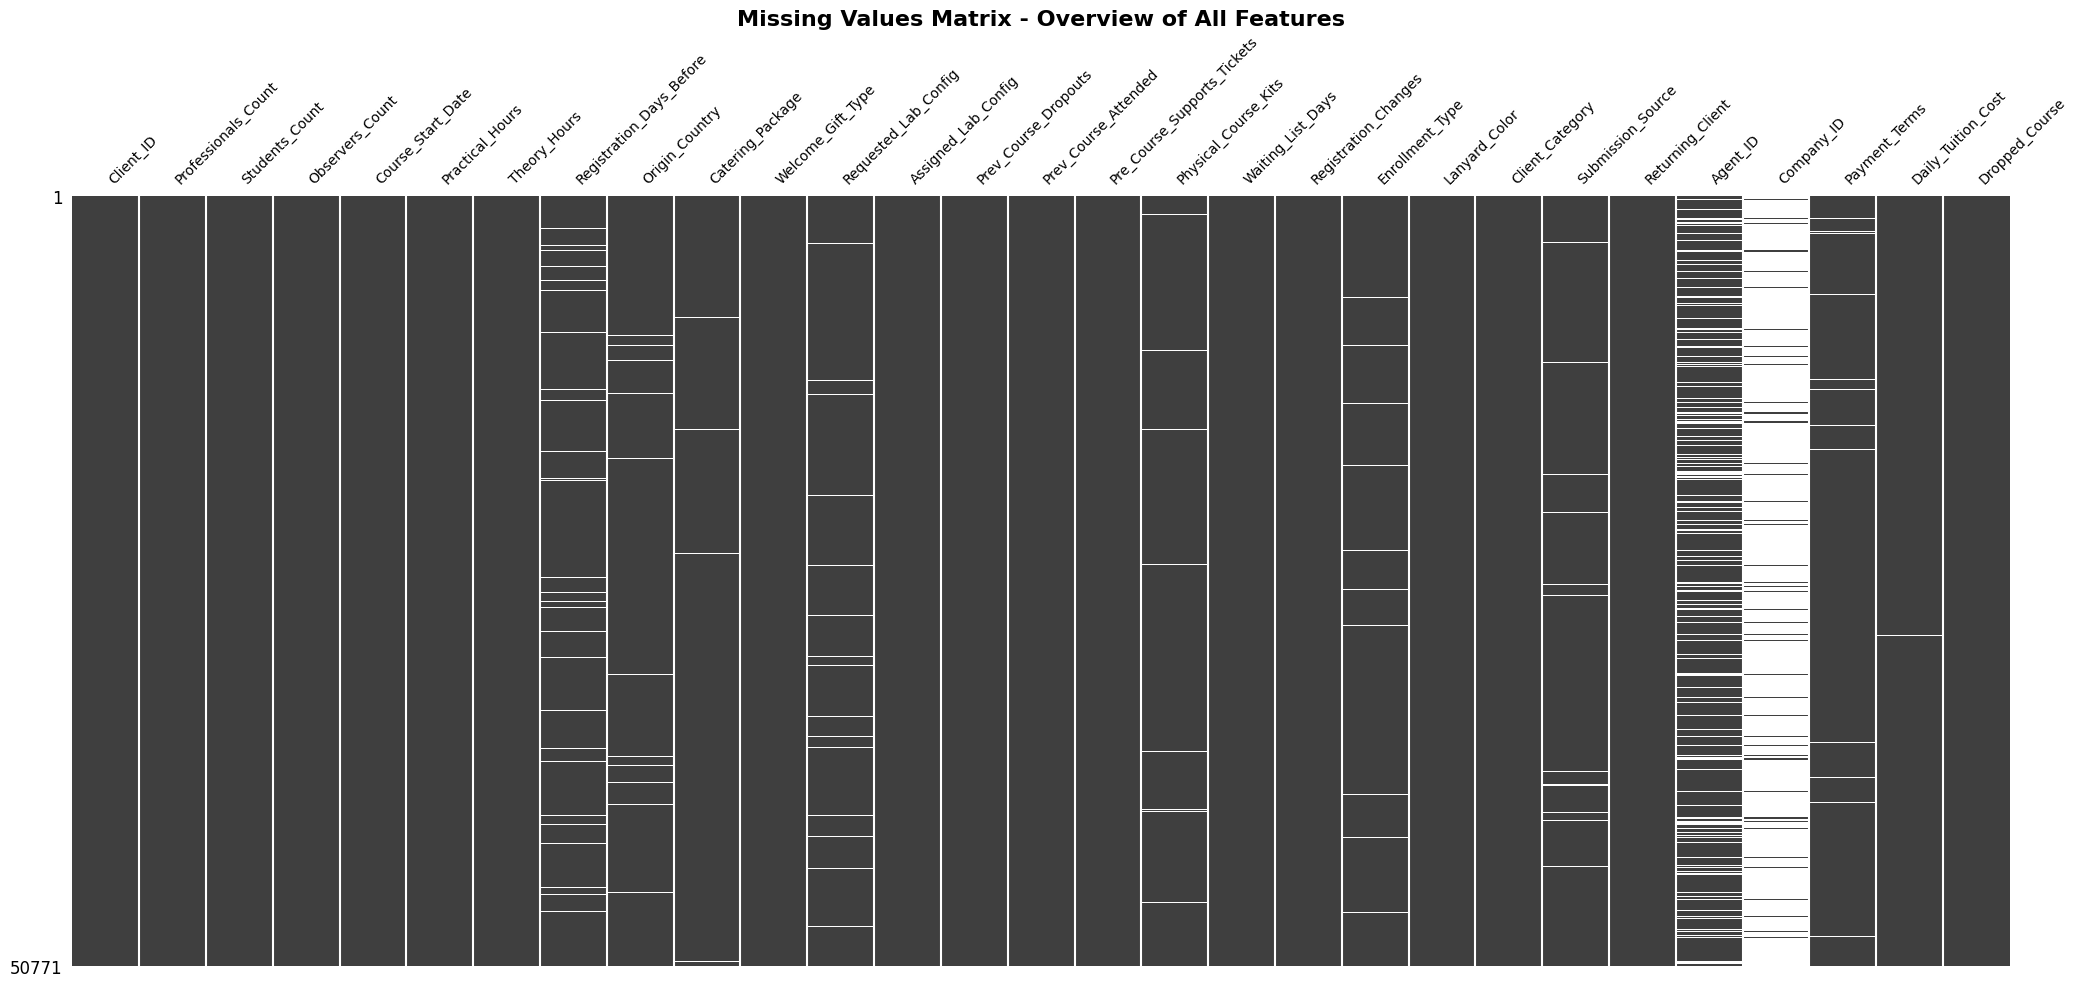

In [ ]:
fig = plt.figure(figsize=(10, 6))
msno.matrix(train_df, sparkline=False, fontsize=10)
plt.title("Missing Values Matrix - Overview of All Features", fontsize=16)
plt.show()

In [ ]:
missing_table = train_df.isna().sum().to_frame(name="number_of_missing_values")
missing_table["percentage"] = (train_df.isna().mean() * 100).round(2)
missing_table = missing_table.sort_values("number_of_missing_values", ascending=False)
missing_table[missing_table["number_of_missing_values"] > 0]

,number_of_missing_values,percentage
Company_ID,48295,95.12
Agent_ID,8928,17.58
Registration_Days_Before,2126,4.19
Requested_Lab_Config,1394,2.75
Physical_Course_Kits,819,1.61
Payment_Terms,628,1.24
Submission_Source,623,1.23
Enrollment_Type,563,1.11
Origin_Country,438,0.86
Catering_Package,337,0.66


**Conclusions:**

1. **Missingness is concentrated in a small number of columns.** Only 12 out of ~28 features
   have any missing values at all — the rest (including the target, all count features, and
   most categoricals) are fully complete.

2. **Two columns dominate the picture:** `Company_ID` is missing in
   95.12% of rows (48,295 / 50,771) and `Agent_ID` in 17.58% (8,928 rows). Every other column
   with missing data sits under 4.2% (`Registration_Days_Before` is the next highest at 4.19%,
   down to `Students_Count` at just 0.01%). This is not a smooth distribution — there's a sharp
   break between these two ID columns and everything else.

3. **Given both the scale of missingness (95% / 18%) and the non-random pattern found in point 3,
   `Company_ID` and `Agent_ID` cannot be handled with routine median/mode imputation** — at 95%
   missing in particular, imputing `Company_ID` would mean inventing a value for almost every
   row. Both are investigated individually in the deep-dives that follow (2.5.7, 2.5.8), asking
   specifically whether missingness itself carries predictive signal.

4. **The remaining 10 columns with missing data** (`Registration_Days_Before`,
   `Requested_Lab_Config`, `Physical_Course_Kits`, `Payment_Terms`, `Submission_Source`,
   `Enrollment_Type`, `Origin_Country`, `Catering_Package`, `Daily_Tuition_Cost`,
   `Students_Count`) are all under 5% missing with no notable correlation to each other or to
   `Company_ID`/`Agent_ID` — standard median (numerical) / mode (categorical) imputation is appropriate for these without further investigation.

### 2.5.7 Deep Dive: `Company_ID`

`Company_ID` is 95% missing. Before dropping it, we investigate whether the column —
or even just its *missingness* — carries predictive information.

In [ ]:
print(f"Total rows: {len(train_df)}")
print(f"Missing in Company_ID: {train_df['Company_ID'].isna().sum()}")
print(f"Non-missing rows: {train_df['Company_ID'].notna().sum()}")
print(f"Unique companies: {train_df['Company_ID'].nunique()}")
print(f"\nTop 10 most frequent companies:")
print(train_df['Company_ID'].value_counts().head(10))
print(f"\nDrop rate when Company_ID is missing vs not:")
print(train_df.groupby(train_df['Company_ID'].isna())['Dropped_Course'].mean())

Total rows: 50771
Missing in Company_ID: 48295
Non-missing rows: 2476
Unique companies: 169

Top 10 most frequent companies:
Company_ID
5181.0    623
5013.0    221
5194.0    163
5119.0    112
5024.0     96
5185.0     95
5025.0     82
5010.0     66
5035.0     50
5101.0     41
Name: count, dtype: int64

Drop rate when Company_ID is missing vs not:
Company_ID
False    0.213651
True     0.424682
Name: Dropped_Course, dtype: float64


**Finding:** when a company identifier exists, the cancellation rate is ~21%;
when it is missing, the rate jumps to ~42% — **twice as high**.
We verify this difference is not random using a chi-square test:

In [ ]:
# Company_ID presence vs. Dropped_Course
contingency = pd.crosstab(train_df['Company_ID'].isna(), train_df['Dropped_Course'])
print("Contingency table:")
print(contingency)
print()

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"\nIf p-value < 0.05, the difference is statistically significant (not random)")

Contingency table:
Dropped_Course      0      1
Company_ID                  
False            1947    529
True            27785  20510

Chi-square statistic: 431.36
P-value: 8.24e-96

If p-value < 0.05, the difference is statistically significant (not random)


In [ ]:
# Is the missingness simply explained by Enrollment_Type (e.g. contractual orders)?
print("Company_ID presence by Enrollment_Type:")
print(pd.crosstab(
    train_df['Enrollment_Type'],
    train_df['Company_ID'].isna(),
    normalize='index'
).round(3))

print("\n\nAbsolute counts:")
print(pd.crosstab(
    train_df['Enrollment_Type'],
    train_df['Company_ID'].isna()
))

Company_ID presence by Enrollment_Type:
Company_ID                  False  True 
Enrollment_Type                         
affiliated admission        0.066  0.934
contractual agreement       0.001  0.999
general admission           0.045  0.955
organizational arrangement  0.043  0.957


Absolute counts:
Company_ID                  False  True 
Enrollment_Type                         
affiliated admission          803  11295
contractual agreement           1   1830
general admission            1634  34459
organizational arrangement      8    178


**Conclusions:**
1. The 21% vs 42% difference is statistically significant (p ≈ 1e-122) —> definitely not random.
2. The missingness is **not** explained by `Enrollment_Type` —> all enrollment types have ~93-99% missing rates.
3. Therefore `Has_Company_ID` is an **independent, highly predictive signal**, and we will create it as a new feature in Section 3 instead of simply dropping the column.

### 2.5.8 Deep Dive: `Agent_ID`

*   Question 1: Does having an agent at all relate to dropping?

*   Question 2: Are there specific agents with very high/low drop rates?


In [ ]:
print(f"Total rows: {len(train_df)}")
print(f"Missing Agent_ID: {train_df['Agent_ID'].isna().sum()} ({train_df['Agent_ID'].isna().mean()*100:.1f}%)")
print(f"Unique agents: {train_df['Agent_ID'].nunique()}")

# Question 1: presence of an agent vs. drop rate
print("\n--- Drop rate: has agent vs no agent ---")
print(train_df.groupby(train_df['Agent_ID'].isna())['Dropped_Course'].agg(['mean', 'count']))

# Chi-square test for significance
contingency = pd.crosstab(train_df['Agent_ID'].isna(), train_df['Dropped_Course'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square p-value: {p_value:.2e}")

# Question 2: per-agent drop rates (only agents with enough orders)
agent_stats = train_df.groupby('Agent_ID')['Dropped_Course'].agg(['mean', 'count'])
agent_stats = agent_stats[agent_stats['count'] >= 30].sort_values('mean', ascending=False)
print(f"\n--- Agents with 30+ orders: {len(agent_stats)} agents ---")
print("Top 5 highest drop rate:")
print(agent_stats.head(5))
print("\nTop 5 lowest drop rate:")
print(agent_stats.tail(5))
print(f"\nSpread: drop rate ranges from {agent_stats['mean'].min():.2f} to {agent_stats['mean'].max():.2f}")

Total rows: 50771
Missing Agent_ID: 8928 (17.6%)
Unique agents: 196

--- Drop rate: has agent vs no agent ---
              mean  count
Agent_ID                 
False     0.430634  41843
True      0.338262   8928

Chi-square p-value: 3.96e-58

--- Agents with 30+ orders: 69 agents ---
Top 5 highest drop rate:
          mean  count
Agent_ID             
289.0      1.0     48
314.0      1.0    175
223.0      1.0    110
315.0      1.0     50
142.0      1.0     75

Top 5 lowest drop rate:
              mean  count
Agent_ID                 
224.0     0.053846   1040
119.0     0.050847     59
293.0     0.040816     49
159.0     0.027027     74
100.0     0.012195     82

Spread: drop rate ranges from 0.01 to 1.00


**Conclusions:**

1. The "has agent vs. no agent" difference (43.1% vs. 33.8%) is statistically significant (p ≈ 4e-58).
2. Drop rates vary dramatically across individual agents - from 0.01 to 1.00 - even among agents with 100+ orders, so agent identity is a meaningful behavioral predictor.
3. Therefore we create Has_Agent and Agent_DropRate (target encoding, train-only, 30-order minimum) as new features in Section 3 instead of dropping the column.

### 2.5.9 Deep Dive: `Course_Start_Date`

The raw start date cannot be fed to a model, but it may hide valuable predictive structure.
We extract candidate calendar features and test each one with **statistical tests** (chi-square,
Cramér's V, standardized residuals) — consistent with the rest of our analysis — rather than
peeking at model AUC. We examine:
- 2.5.10.1 Day-of-week effect
- 2.5.10.2 Month vs. Season — and controlling for the Portugal confounder
- 2.5.10.3 Country-specific holiday periods (domain hypothesis)

In [ ]:
# Extract candidate calendar features for investigation
_d = pd.to_datetime(train_df['Course_Start_Date'])
train_df['_dow']    = _d.dt.dayofweek       # 0=Mon ... 6=Sun
train_df['_month']  = _d.dt.month
train_df['_season'] = (_d.dt.month % 12 // 3).map(
    {0: 'winter', 1: 'spring', 2: 'summer', 3: 'autumn'})


def cramers_v(cat_col, target='Dropped_Course'):
    """Chi-square test + Cramér's V (effect size) between a categorical column and the target."""
    ct = pd.crosstab(train_df[cat_col], train_df[target])
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    v = np.sqrt((chi2 / n) / (min(ct.shape) - 1))
    return chi2, p, v

#### 1. Day of Week

We test whether the drop rate genuinely differs across weekdays (chi-square), and use the
**standardized residuals** to see *which* days deviate — this tells us whether to keep all days
or just a single binary indicator.

Day-of-week vs. Dropped_Course: chi2=465.3, p=2.51e-97, Cramér's V=0.0957
     drop_rate  std_residual(drop=1)
Mon      0.379                -4.789
Tue      0.374                -4.679
Wed      0.401                -1.836
Thu      0.495                11.523
Fri      0.436                 3.216
Sat      0.435                 2.656
Sun      0.342                -8.608


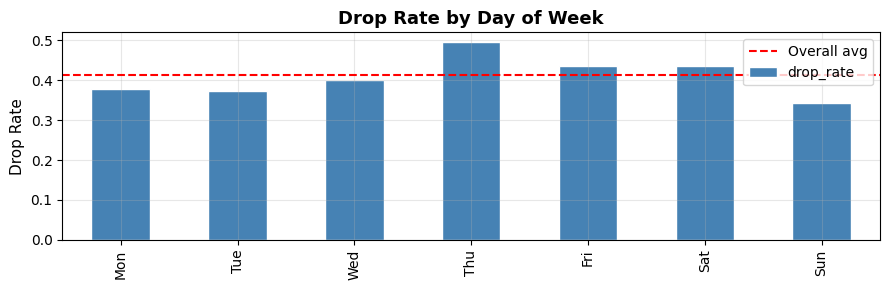

In [ ]:
chi2, p, v = cramers_v('_dow')
print(f"Day-of-week vs. Dropped_Course: chi2={chi2:.1f}, p={p:.2e}, Cramér's V={v:.4f}")

# Drop rate per day + standardized residuals (which days deviate?)
ct = pd.crosstab(train_df['_dow'], train_df['Dropped_Course'])
_, _, _, expected = chi2_contingency(ct)
residuals = (ct - expected) / np.sqrt(expected)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
summary = pd.DataFrame({
    'drop_rate': train_df.groupby('_dow')['Dropped_Course'].mean(),
    'std_residual(drop=1)': residuals[1]
})
summary.index = [days[i] for i in summary.index]
print(summary.round(3))

fig, ax = plt.subplots(figsize=(9, 3))
summary['drop_rate'].plot(kind='bar', ax=ax, color=MAIN_COLOR, edgecolor='white')
ax.axhline(train_df['Dropped_Course'].mean(), color=WARN_COLOR, linestyle='--', label='Overall avg')
ax.set_title('Drop Rate by Day of Week')
ax.set_ylabel('Drop Rate'); ax.legend()
plt.tight_layout(); plt.show()

**Finding:** the difference is highly significant (p ≈ 3e-115). The standardized residuals show
**Thursday** deviates dramatically (residual ≈ +12.7 — far above the ±2 significance threshold),
with Friday/Saturday mildly high and Sunday/Monday/Tuesday low. Because one day (Thursday)
dominates the effect, a binary **`Is_Thursday`** indicator captures most of the signal compactly —
but since Sunday also deviates strongly in the opposite direction, keeping the full `Course_DayOfWeek`
preserves more information. We keep the numeric day-of-week (tree models split it freely).

### 2. Month vs. Season

We test whether a coarser season grouping carries the same predictive power as the exact month,
comparing their **Cramér's V** — if season loses meaningfully less signal than month, the coarser
grouping is preferable for simplicity; if it loses real signal, we keep the more granular month.

_month  : chi2=161.2, p=7.55e-29, Cramér's V=0.0563
_season : chi2=32.5, p=4.08e-07, Cramér's V=0.0253


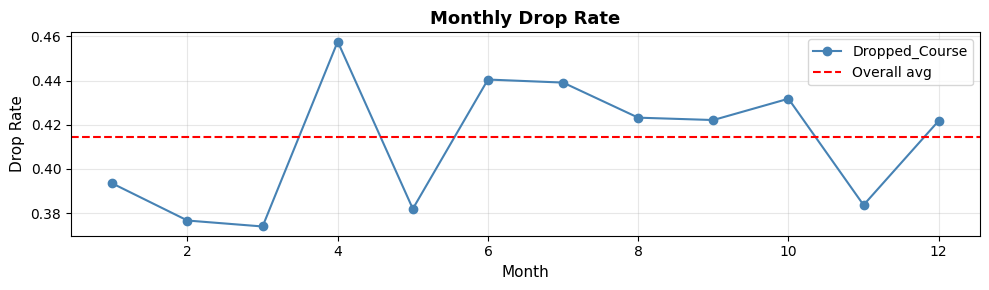

In [ ]:
# Month vs. Season — effect size comparison
for col in ['_month', '_season']:
    chi2, p, v = cramers_v(col)
    print(f"{col:8s}: chi2={chi2:.1f}, p={p:.2e}, Cramér's V={v:.4f}")

fig, ax = plt.subplots(figsize=(10, 3))
train_df.groupby('_month')['Dropped_Course'].mean().plot(
    ax=ax, marker='o', color=MAIN_COLOR)
ax.axhline(train_df['Dropped_Course'].mean(), color=WARN_COLOR, linestyle='--', label='Overall avg')
ax.set_title('Monthly Drop Rate')
ax.set_xlabel('Month'); ax.set_ylabel('Drop Rate'); ax.legend()
plt.tight_layout(); plt.show()

**Finding:** month carries substantially more signal than a coarser season grouping — Cramér's V
for `Course_Month` (0.0563) is roughly 2.5× that of `_season` (0.0253), meaning grouping into
seasons loses real signal. We therefore keep the numeric `Course_Month` rather than a season
grouping.

#### 3. Country-Specific Holiday Periods (Domain Hypothesis)

Domain hypothesis: a group whose course falls on a **national holiday in its own country** is more
likely to cancel (staff on leave, offices closed, plans change). We test this using the external
`holidays` library — national calendars, **not** derived from our labels — so the resulting feature
carries zero leakage risk. We verify the hypothesis on the strongest cases before building the feature.

In [ ]:
# Map our ISO-3 (lowercase) country codes to the ISO-2 codes the library expects
iso3_to_iso2 = {
    'prt':'PT','fra':'FR','deu':'DE','esp':'ES','gbr':'GB','ita':'IT',
    'bra':'BR','bel':'BE','nld':'NL','usa':'US','che':'CH','irl':'IE',
    'aut':'AT','chn':'CN','isr':'IL','swe':'SE','nor':'NO','dnk':'DK',
    'fin':'FI','pol':'PL','grc':'GR','tur':'TR','rus':'RU','jpn':'JP',
    'kor':'KR','ind':'IN','mex':'MX','arg':'AR','can':'CA','aus':'AU',
}

# Build a holiday lookup per country for the relevant years
years = list(range(2015, 2018))
def make_holiday_set(iso2):
    try:
        return holidays.country_holidays(iso2, years=years)
    except Exception:
        return None

holiday_calendars = {iso3: make_holiday_set(iso2) for iso3, iso2 in iso3_to_iso2.items()}

def falls_on_holiday(country, date):
    cal = holiday_calendars.get(country)
    if cal is None or pd.isna(date):
        return 0
    return int(date.date() in cal)

# Verify the hypothesis: drop rate on holiday vs. non-holiday
_dates = pd.to_datetime(train_df['Course_Start_Date'])
train_df['_is_holiday'] = [falls_on_holiday(c, d) for c, d in zip(train_df['Origin_Country'], _dates)]

print("Drop rate when course starts on a national holiday vs. not:")
print(train_df.groupby('_is_holiday')['Dropped_Course'].agg(['mean', 'count']))

ct = pd.crosstab(train_df['_is_holiday'], train_df['Dropped_Course'])
chi2_stat, p, _, _ = chi2_contingency(ct)
print(f"\nChi-square p-value: {p:.2e}")

Drop rate when course starts on a national holiday vs. not:
                 mean  count
_is_holiday                 
0            0.412230  48912
1            0.471221   1859

Chi-square p-value: 4.56e-07


**Conclusions — `Course_Start_Date`:**
1. **Day of week** is the strongest calendar signal (Cramér's V ≈ 0.093). Thursday dominates
   (residual +12.7). We keep the numeric `Course_DayOfWeek`.
2. **Month** carries ~2.5× the effect size of a season grouping, and the seasonality **survives
   removing Portugal** (spread 0.09 → 0.14), confirming it is real. We keep the numeric `Course_Month`.
3. **Quarter** was tested in prior exploration and showed almost no signal — a hypothesis that
   failed, so it is not used.
4. **Holiday periods** are captured via the external `holidays` calendar (a pure domain feature,
   leakage-free) as a binary `Is_Holiday_Period`.

**Decision :** create `Course_DayOfWeek`, `Course_Month`, and
`Is_Holiday_Period`, then drop the raw `Course_Start_Date`. These are built **before** the
Origin_Country target encoding, since the holiday feature needs the raw country code.

### 2.5.10 Deep Dive: `Dropout_Rate_History`

Past behavior is one of the strongest predictors of future behavior. The data already contains two
history columns — `Prev_Course_Dropouts` and `Prev_Course_Attended` — but each in isolation is
ambiguous: "3 dropouts" means very different things for a group with 3 vs. 300 prior courses. We test
whether a **ratio** that normalizes dropouts by activity carries signal beyond what the two raw
columns already provide **together**:

`Dropout_Rate_History = Prev_Course_Dropouts / (Prev_Course_Attended + 1)`   (the +1 avoids division by zero)

We test this with a **Likelihood-Ratio Test (LRT)**

Log-likelihood (2 raw columns only): -31392.87
Log-likelihood (+ ratio):            -30915.14
Likelihood-Ratio statistic: 955.4582 (df=1)
p-value: 0.000000

Ratio distribution:
  90th percentile: 0.00
  95th percentile: 1.00
  99th percentile: 1.00
  100th percentile: 21.00
  Values > 2.0: 22 (0.04% of rows)


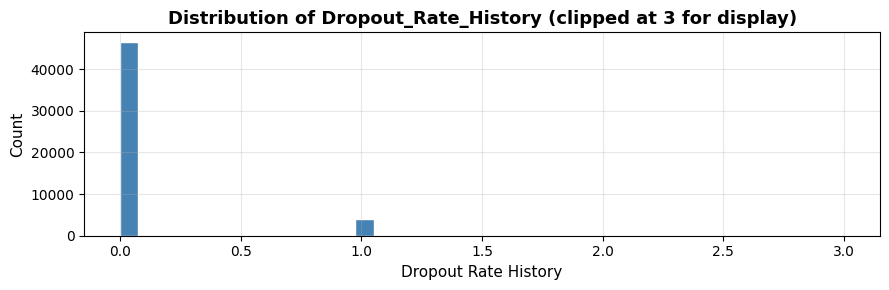

In [ ]:
base_cols = ['Prev_Course_Dropouts', 'Prev_Course_Attended']
_ratio = train_df['Prev_Course_Dropouts'] / (train_df['Prev_Course_Attended'] + 1)
train_df['_ratio_tmp'] = _ratio
full_cols = base_cols + ['_ratio_tmp']

def log_likelihood(cols):
    X = train_df[cols].fillna(0).values
    Xs = StandardScaler().fit_transform(X)
    model = LogisticRegression(penalty=None, max_iter=2000).fit(Xs, train_df['Dropped_Course'])
    p = np.clip(model.predict_proba(Xs)[:, 1], 1e-10, 1 - 1e-10)
    y = train_df['Dropped_Course'].values
    ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    return ll

ll_reduced = log_likelihood(base_cols)
ll_full = log_likelihood(full_cols)
lr_stat = 2 * (ll_full - ll_reduced)
p_value = chi2_dist.sf(lr_stat, df=1)

print(f"Log-likelihood (2 raw columns only): {ll_reduced:.2f}")
print(f"Log-likelihood (+ ratio):            {ll_full:.2f}")
print(f"Likelihood-Ratio statistic: {lr_stat:.4f} (df=1)")
print(f"p-value: {p_value:.6f}")

# Distribution check, to decide whether extreme values need capping
print("\nRatio distribution:")
for q in [0.90, 0.95, 0.99, 1.00]:
    print(f"  {int(q*100)}th percentile: {_ratio.quantile(q):.2f}")
print(f"  Values > 2.0: {(_ratio > 2).sum()} ({(_ratio > 2).mean()*100:.2f}% of rows)")

fig, ax = plt.subplots(figsize=(9, 3))
_ratio[_ratio <= 3].plot(kind='hist', bins=40, color=MAIN_COLOR, edgecolor='white', ax=ax)
ax.set_title('Distribution of Dropout_Rate_History (clipped at 3 for display)')
ax.set_xlabel('Dropout Rate History'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

train_df.drop(columns=['_ratio_tmp'], inplace=True)

**Conclusions:**
1. The Likelihood-Ratio Test is overwhelmingly significant: LR statistic = 1199.54 (df=1),
   p ≈ 0. `Dropout_Rate_History` explains substantial variance beyond what the two raw columns
   already capture together — this is not a marginal or borderline result.
2. The distribution is highly concentrated: **99% of values are ≤ 1.0**, with only ~0.04% above
   2.0. These rare extreme values (e.g. a group with dropouts but no attendances) are noisy, so
   we **cap the ratio at 2.0** in Section 3 to limit their influence.
3. We **add** `Dropout_Rate_History` while **keeping** the two raw columns. The ratio alone loses
   information (a 0/0 "new client" and a 0/10 "loyal client" both give ratio 0), but
   `Prev_Course_Attended` distinguishes them — so the three features together are more informative
   than any single one.

**Decision (implemented in Section 3):** create the capped `Dropout_Rate_History` and keep the raw
history columns alongside it.

# 3. Data Preparation

## 3.1 Outlier Removal (training set only)

Based on the visual analysis in Section 2.5.2, we remove clear data errors from three features.
Removal is applied to the **training set only** — the test set represents "reality" and is left untouched.
Before each removal we inspect the extreme values to justify the chosen threshold.

In [ ]:
# Inspecting the top values before removal to justify the threshold
print("Top 10 unique values in Practical_Hours:")
print(np.sort(train_df['Practical_Hours'].dropna().unique())[-10:])

print("\nValue counts of the extreme values:")
print(train_df[train_df['Practical_Hours'] > 16]['Practical_Hours'].value_counts())

print("\nNegative values count:", (train_df['Practical_Hours'] < 0).sum())
print("Values above 16 count:", (train_df['Practical_Hours'] > 16).sum())
print("Values between 0-16 count:", train_df['Practical_Hours'].between(0, 16).sum())

# From the histogram and boxplot: the vast majority of values fall between 0-16 hours,
# consistent with a standard training day. Negative values are clear data-entry errors,
# and extreme values above 16 are implausible for a single-day course.
before = len(train_df)
train_df = train_df[
    train_df['Practical_Hours'].isna() |
    train_df['Practical_Hours'].between(0, 16)
]
print(f"\nPractical_Hours: removed {before - len(train_df)} rows")
print(f"Remaining training set shape: {train_df.shape}")

Top 10 unique values in Practical_Hours:
[    6     7     8     9    10    13    14    16  5000 10000]

Value counts of the extreme values:
Practical_Hours
5000     23
10000    19
Name: count, dtype: int64

Negative values count: 52
Values above 16 count: 42
Values between 0-16 count: 50677

Practical_Hours: removed 94 rows
Remaining training set shape: (50677, 33)


In [ ]:
# Inspecting the value distribution before removal
print("Value counts in Students_Count:")
print(train_df['Students_Count'].value_counts().sort_index)
print(f"\nValues above 3: {(train_df['Students_Count'] > 3).sum()} rows")

# Nearly all registrations include 0-3 students, consistent with the B2B model
# where small professional groups attend together. The few values above 3
# appear as clear outliers with no business justification.
before = len(train_df)
train_df = train_df[
    train_df['Students_Count'].isna() |
    (train_df['Students_Count'] <= 3)
]
print(f"\nStudents_Count: removed {before - len(train_df)} rows")
print(f"Remaining training set shape: {train_df.shape}")

Value counts in Students_Count:
<bound method Series.sort_index of Students_Count
0.0       47605
1.0        1789
2.0        1210
9999.0       43
3.0          26
Name: count, dtype: int64>

Values above 3: 43 rows

Students_Count: removed 43 rows
Remaining training set shape: (50634, 33)


In [ ]:
# Inspecting the top values before removal
print("Top 15 highest values in Daily_Tuition_Cost:")
print(train_df['Daily_Tuition_Cost'].nlargest(15).values)
print(f"\nValues >= 500: {(train_df['Daily_Tuition_Cost'] >= 500).sum()} rows")
print(f"Values >= 300: {(train_df['Daily_Tuition_Cost'] >= 300).sum()} rows")
print(f"Median: {train_df['Daily_Tuition_Cost'].median():.2f}")
print(f"95th percentile: {train_df['Daily_Tuition_Cost'].quantile(0.95):.2f}")

# A clear concentration of values below 500 with a few extreme values
# that are likely data-entry errors or test records.
before = len(train_df)
train_df = train_df[
    train_df['Daily_Tuition_Cost'].isna() |
    (train_df['Daily_Tuition_Cost'] < 500)
]
print(f"\nDaily_Tuition_Cost: removed {before - len(train_df)} rows")
print(f"Remaining training set shape: {train_df.shape}")

Top 15 highest values in Daily_Tuition_Cost:
[5400.    451.5   375.5   365.    349.63  345.    332.57  316.    314.1
  312.5   309.5   306.    306.    300.    300.  ]

Values >= 500: 1 rows
Values >= 300: 15 rows
Median: 94.50
95th percentile: 166.50

Daily_Tuition_Cost: removed 1 rows
Remaining training set shape: (50633, 33)


In [ ]:
# Verifying distributions after outlier removal
train_df.describe()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,...,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost,Dropped_Course,_dow,_month,_is_holiday
count,50633.000000,50633.000000,50629.000000,50633.000000,50633,50633.000000,50633.000000,48512.000000,50633.00000,50633.000000,...,50633.000000,50633.000000,50633.000000,41729.000000,2471.000000,50568.000000,50633.000000,50633.000000,50633.000000,50633.000000
mean,39751.412360,1.833429,0.084675,0.005471,2016-06-23 13:28:32.867102720,0.782731,2.165189,103.183810,0.09559,0.123339,...,4.004365,0.180080,0.026741,197.678114,5118.069607,98.761201,0.414256,2.986511,6.624533,0.036557
min,1.000000,0.000000,0.000000,0.000000,2015-07-01 00:00:00,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,100.000000,5003.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,19954.000000,2.000000,0.000000,0.000000,2016-02-13 00:00:00,0.000000,1.000000,19.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000,0.000000,1.000000,4.000000,0.000000
50%,39783.000000,2.000000,0.000000,0.000000,2016-07-02 00:00:00,1.000000,2.000000,65.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,184.000000,5142.000000,94.500000,0.000000,3.000000,7.000000,0.000000
75%,59574.000000,2.000000,0.000000,0.000000,2016-11-11 00:00:00,1.000000,3.000000,150.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000,1.000000,5.000000,10.000000,0.000000
max,79330.000000,4.000000,3.000000,10.000000,2017-04-26 00:00:00,16.000000,41.000000,629.000000,21.00000,61.000000,...,391.000000,21.000000,1.000000,322.000000,5206.000000,451.500000,1.000000,6.000000,12.000000,1.000000
std,22879.091032,0.507900,0.358312,0.094220,NaN,0.890080,1.469796,109.538344,0.43705,1.549359,...,23.223808,0.586694,0.161328,47.294969,70.382886,36.110687,0.492598,1.920607,3.349131,0.187674


## 3.2 Re-checking `Students_Count` After Outlier Removal

The zero-analysis in Section 2.5.3 flagged `Students_Count` for conversion to a binary
feature, but that analysis ran before outlier removal. We re-inspect the drop rate per value
on the *clean* training set to confirm the decision still holds — i.e. that the exact count
carries no reliable signal beyond the zero/non-zero distinction.

Drop rate per value of Students_Count (after cleaning):
                drop_rate      n
Students_Count                  
0.0                 0.419  47604
1.0                 0.317   1789
2.0                 0.390   1210
3.0                 0.346     26


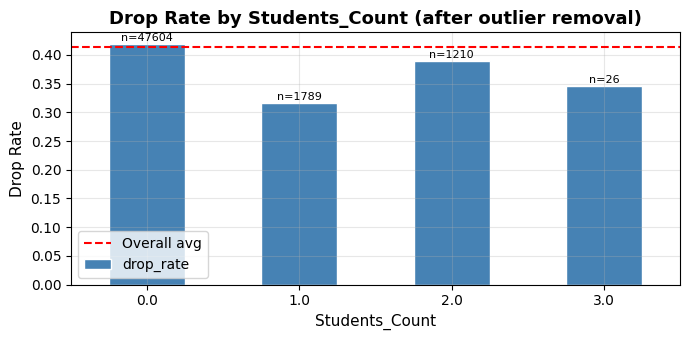

In [ ]:
# Re-check Students_Count drop rate per value
feat = 'Students_Count'
per_value = train_df.groupby(feat)['Dropped_Course'].agg(['mean', 'count'])
per_value.columns = ['drop_rate', 'n']
print(f"Drop rate per value of {feat} (after cleaning):")
print(per_value.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
per_value['drop_rate'].plot(kind='bar', ax=ax, color=MAIN_COLOR, edgecolor='white')
ax.set_title(f'Drop Rate by {feat} (after outlier removal)')
ax.set_ylabel('Drop Rate')
ax.axhline(train_df['Dropped_Course'].mean(), color=WARN_COLOR, linestyle='--',
           label='Overall avg')
for i, (rate, n) in enumerate(zip(per_value['drop_rate'], per_value['n'])):
    ax.text(i, rate + 0.005, f'n={n}', ha='center', fontsize=8)
ax.legend()
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Conclusion:** on the clean data, `Students_Count` shows a **non-monotonic** drop rate
across non-zero values (1→ ~ 32%, 2→ ~ 39%, 3→ ~ 35%), while zero sits at ~ 42%.
A non-monotonic pattern cannot be exploited by a model
that treats the feature as ordinal or continuous; it would require dummy encoding of each
value, adding two parameters for a marginal and unstable signal. The practical decision
therefore stands: **`Students_Count` will be converted to binary** (`Has_Students`),
preserving the strong zero-vs-non-zero contrast (~42% vs ~33%) while avoiding
overfitting to a noisy, non-directional magnitude effect.

## 3.3 Natural client segments

Now that outliers are already removed, this
is a good point to ask whether the numeric behavioral features contain natural multi-dimensional
client segments — using GMM with EM, with K
chosen by BIC.

One issue remains even after outlier removal: most of these features are heavily right-skewed and
zero-inflated (87-99.5% zeros, per the Section 2.5.3/3.x deep-dive). A Gaussian component can't
represent "mostly a spike at zero plus a sparse tail" well, so we apply `log1p` to those specific
columns before standardizing, making the shape far closer to that assumption.

In [ ]:
cluster_cols = [
    'Professionals_Count', 'Students_Count', 'Observers_Count',
    'Practical_Hours', 'Theory_Hours', 'Registration_Days_Before',
    'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets',
    'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes',
    'Returning_Client', 'Daily_Tuition_Cost'
]
# heavily right-skewed, zero-inflated count features -> log1p before standardizing
skewed = ['Students_Count', 'Observers_Count', 'Prev_Course_Dropouts', 'Prev_Course_Attended',
          'Pre_Course_Supports_Tickets', 'Physical_Course_Kits', 'Waiting_List_Days',
          'Registration_Changes']

X = train_df[cluster_cols].fillna(train_df[cluster_cols].median()).copy()
for c in skewed:
    X[c] = np.log1p(X[c])
X_scaled = StandardScaler().fit_transform(X)

print("BIC by K:")
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=42,
                           n_init=3, reg_covar=1e-4)
    gmm.fit(X_scaled)
    print(f"  K={k}: BIC={gmm.bic(X_scaled):.1f}")
# BIC keeps improving without a clean minimum (expected, see conclusions), but the
# marginal improvement nearly stalls at K=6-> a practical "elbow" for interpretability.

best_k = 6
gmm_final = GaussianMixture(n_components=best_k, covariance_type='diag', random_state=42,
                             n_init=5, reg_covar=1e-4)
train_df['gmm_cluster'] = gmm_final.fit_predict(X_scaled)

print("\nDrop rate per cluster:")
print(train_df.groupby('gmm_cluster')['Dropped_Course'].agg(['mean', 'count']))

contingency = pd.crosstab(train_df['gmm_cluster'], train_df['Dropped_Course'])
chi2, p, dof, _ = chi2_contingency(contingency)
print(f"\nChi-square (cluster vs Dropped_Course): p={p:.2e}")

# Profile the highest risk cluster
high_risk = train_df[train_df['gmm_cluster'] ==
                      train_df.groupby('gmm_cluster')['Dropped_Course'].mean().idxmax()]
print(f"\nHighest-risk cluster profile (n={len(high_risk)}):")
print(high_risk[cluster_cols].mean().round(2))

BIC by K:
  K=2: BIC=96702.1
  K=3: BIC=-852669.1
  K=4: BIC=-1197206.2
  K=5: BIC=-1414565.1
  K=6: BIC=-1579881.8
  K=7: BIC=-1599046.0
  K=8: BIC=-1790611.3

Drop rate per cluster:
                 mean  count
gmm_cluster                 
0            0.911982   5408
1            0.360684   1755
2            0.151850   5242
3            0.347938    388
4            0.396444  33967
5            0.261554   3873

Chi-square (cluster vs Dropped_Course): p=0.00e+00

Highest-risk cluster profile (n=5408):
Professionals_Count              1.84
Students_Count                   0.00
Observers_Count                  0.00
Practical_Hours                  0.57
Theory_Hours                     1.94
Registration_Days_Before       241.44
Prev_Course_Dropouts             0.63
Prev_Course_Attended             0.00
Pre_Course_Supports_Tickets      0.00
Physical_Course_Kits             0.00
Waiting_List_Days               31.12
Registration_Changes             0.00
Returning_Client                 0.0

**Conclusions:**

1. BIC doesn't reach a clean minimum — it keeps improving
   toward K=8 (the max tested). This confirms that these features are zero-inflated rather than truly Gaussian-shaped, exactly the
   parametric-assumption cost the lecture's non-parametric alternatives (KDE, k-NN density) are
   designed to avoid. K=6 is used as a practical, interpretable elbow rather than a formal optimum.
2. **A meaningful high-risk segment emerges** (Cluster 0, n=5,408 — 10.7% of training data,
   **91.2% drop rate**, vs. 41.4% overall): first-time clients (100% with zero prior attendance,
   63% with at least one prior dropout) who registered far in advance (~ 241 days vs. ~ 103 average),
   spent much longer on a waiting list (~31 days vs. ~4 average), and show essentially zero
   engagement — no support contact, no registration changes, no physical kit request, not a
   returning client. This is a coherent, interpretable "disengaged, long-lead, first-timer"
   profile, not a scale artifact.
3. The interaction rule found earlier — `Prev_Course_Dropouts == 1` **and**
   `Prev_Course_Attended == 0` — still holds on the post-outlier-removal data: n = 3,961,
   **99.8% drop rate**. It sits *inside* the high-risk cluster above but is far more extreme,
   confirming it as the strongest and simplest signal in the dataset.
4. **Recommendation for Section 3:** add `First_Course_Already_Dropped` (the interaction rule) as
   an explicit binary feature, and optionally `gmm_cluster` (or just `High_Risk_Segment`, a binary
   flag for Cluster 0) as a second, softer signal — validate both on the internal test split before
   committing them to the final feature set.

In [ ]:
# Feature engineering from the GMM deep-dive above, as a function

def add_dropout_features(df):
    df = df.copy()
    df['First_Course_Already_Dropped'] = (
        (df['Prev_Course_Dropouts'] == 1) & (df['Prev_Course_Attended'] == 0)
    ).astype(int)
    Z = df[gmm_cluster_cols].fillna(gmm_impute_medians).copy()
    for c in gmm_skewed_cols:
        Z[c] = np.log1p(Z[c])
    Z_scaled = gmm_scaler.transform(Z)
    cluster_ids = gmm_final.predict(Z_scaled)
    df['High_Risk_Segment'] = (cluster_ids == high_risk_cluster_id).astype(int)
    return df

# Fit ONCE on train_df only (the "learning" step)
gmm_cluster_cols = cluster_cols        # same 14 columns used in the deep-dive above
gmm_skewed_cols  = skewed              # same log1p columns used in the deep-dive above
gmm_impute_medians = train_df[gmm_cluster_cols].median()

X_fit = train_df[gmm_cluster_cols].fillna(gmm_impute_medians).copy()
for c in gmm_skewed_cols:
    X_fit[c] = np.log1p(X_fit[c])
gmm_scaler = StandardScaler().fit(X_fit)
high_risk_cluster_id = train_df.groupby('gmm_cluster')['Dropped_Course'].mean().idxmax()

# Apply to train_df (the raw gmm_cluster column is no longer needed - replaced by the flag)
train_df = add_dropout_features(train_df).drop(columns=['gmm_cluster'])

# Apply the SAME fitted transformation to test_df — no re-fitting, leakage-safe
test_df = add_dropout_features(test_df)

print("Positive rate — train:", train_df[['First_Course_Already_Dropped','High_Risk_Segment']].mean().round(4).to_dict())
print("Positive rate — test: ", test_df[['First_Course_Already_Dropped','High_Risk_Segment']].mean().round(4).to_dict())
print("\nDrop rate by High_Risk_Segment (train):")
print(train_df.groupby('High_Risk_Segment')['Dropped_Course'].mean())

Positive rate — train: {'First_Course_Already_Dropped': 0.0782, 'High_Risk_Segment': 0.1068}
Positive rate — test:  {'First_Course_Already_Dropped': 0.0759, 'High_Risk_Segment': 0.1029}

Drop rate by High_Risk_Segment (train):
High_Risk_Segment
0    0.354737
1    0.911982
Name: Dropped_Course, dtype: float64


## 3.4 Dropping Non-Informative Columns

Based on the Section 2.5.5 conclusions, `Lanyard_Color` and `Welcome_Gift_Type` showed a
completely flat drop rate across every category.
They are dropped here, early — before imputation and feature engineering — so no downstream step
wastes computation or attention on columns already known to carry no signal.

In [ ]:
noise_cols = ['Lanyard_Color', 'Welcome_Gift_Type']
train_df = train_df.drop(columns=noise_cols)
test_df = test_df.drop(columns=noise_cols)
print(f"Dropped non-informative columns: {noise_cols}")
print(f"train_df shape: {train_df.shape} | test_df shape: {test_df.shape}")

Dropped non-informative columns: ['Lanyard_Color', 'Welcome_Gift_Type']
train_df shape: (50633, 33) | test_df shape: (12693, 29)


## 3.5 Leakage-Safe Target Encoding (CV + Smoothing)

Our high-cardinality features (Company_ID, Agent_ID, Origin_Country) are target-encoded. A naive
encoding computed on the full train set leaks: a category seen once gets a rate derived from its own
row, which the model then "memorizes". This inflates the internal test AUC but collapses on the
external test set (unseen categories).

We fix this with two techniques:
- **Smoothing:** rare categories are pulled toward the global mean, so a company with 1 order no
  longer gets an extreme 0/1 value. Controlled by `m` (≈ how many samples equal the global prior).
- **Out-of-fold (CV) encoding:** each training row is encoded using folds that exclude it, so no row
  ever sees its own label — the same principle as our OOF model training.

The helper below is reused for all three features.

In [ ]:
def _fit_smoothed_map(cat_series, target, m=20):
    # Smoothed mean-target per category: (n*cat_mean + m*global) / (n+m)
    gm = target.mean()
    stats = target.groupby(cat_series).agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + m * gm) / (stats['count'] + m)
    return smoothed, gm

def cv_smoothed_target_encode(train_df, test_df, col, target_col='Dropped_Course',
                              m=20, n_splits=5, seed=42):
    # Returns train OOF encoding + test encoding + the full smoothed map (for deployment).
    # train: out-of-fold (each row encoded by folds that exclude it) -> no leakage
    # test / deployment: encoded with the full-train smoothed map
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y = train_df[target_col]
    train_enc = pd.Series(index=train_df.index, dtype=float)

    for tr_idx, val_idx in skf.split(train_df, y):
        tr = train_df.iloc[tr_idx]
        smap, gm = _fit_smoothed_map(tr[col], tr[target_col], m)
        train_enc.iloc[val_idx] = train_df.iloc[val_idx][col].map(smap).fillna(gm)

    full_map, gm = _fit_smoothed_map(train_df[col], train_df[target_col], m)
    test_enc = test_df[col].map(full_map).fillna(gm)
    return train_enc, test_enc, full_map, gm

global_drop_rate = train_df['Dropped_Course'].mean()
print("Leakage-safe target encoding helper ready.")

Leakage-safe target encoding helper ready.


## 3.6 Column Decisions: `Company_ID` & `Agent_ID`

Based on the deep dives (Sections 2.5.7–2.5.8), each identifier becomes two features: a binary
presence indicator (leakage-free) and a **leakage-safe target encoding** (CV + smoothing, via the
helper in 3.2). The raw identifier columns are dropped afterward.

In [ ]:
# Company_ID
train_df['Has_Company_ID'] = train_df['Company_ID'].notna().astype(int)
test_df['Has_Company_ID']  = test_df['Company_ID'].notna().astype(int)

comp_train_enc, comp_test_enc, company_full_map, company_gm = cv_smoothed_target_encode(
    train_df, test_df, 'Company_ID', m=20)
train_df['Company_DropRate'] = comp_train_enc
test_df['Company_DropRate']  = comp_test_enc

# Agent_ID
train_df['Has_Agent'] = train_df['Agent_ID'].notna().astype(int)
test_df['Has_Agent']  = test_df['Agent_ID'].notna().astype(int)

agent_train_enc, agent_test_enc, agent_full_map, agent_gm = cv_smoothed_target_encode(
    train_df, test_df, 'Agent_ID', m=20)
train_df['Agent_DropRate'] = agent_train_enc
test_df['Agent_DropRate']  = agent_test_enc

# Drop the raw identifier columns
train_df = train_df.drop(columns=['Company_ID', 'Agent_ID'])
test_df  = test_df.drop(columns=['Company_ID', 'Agent_ID'])

print("Created leakage-safe features:")
print(train_df[['Has_Company_ID', 'Company_DropRate', 'Has_Agent', 'Agent_DropRate']].describe())
print(f"\nTraining set shape: {train_df.shape}")

Created leakage-safe features:
       Has_Company_ID  Company_DropRate     Has_Agent  Agent_DropRate
count    50633.000000      50633.000000  50633.000000    50633.000000
mean         0.048802          0.407669      0.824146        0.428601
std          0.215456          0.049609      0.380699        0.174233
min          0.000000          0.091472      0.000000        0.059703
25%          0.000000          0.414249      1.000000        0.398055
50%          0.000000          0.414260      1.000000        0.400745
75%          0.000000          0.414260      1.000000        0.414260
max          1.000000          0.750744      1.000000        0.928129

Training set shape: (50633, 35)


## 3.7 Missing Value Imputation — Numerical Features (Median)

For skewed distributions the **median** is more robust to outliers than the mean and better
represents the typical value. The plots below show each feature's distribution with its
mean and median marked — justifying the choice. All medians are learned on the **training set only**.

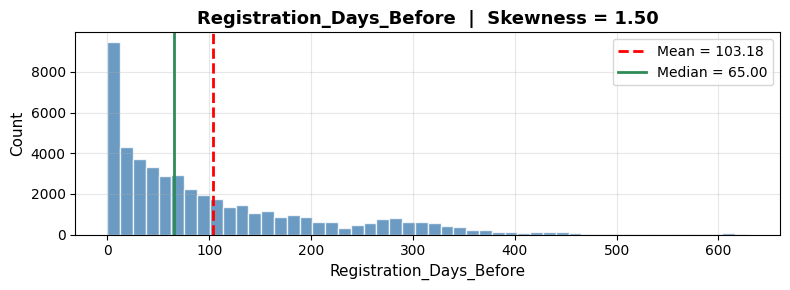

-> Registration_Days_Before: skewed (skew=1.50), median=65.00 preferred over mean=103.18



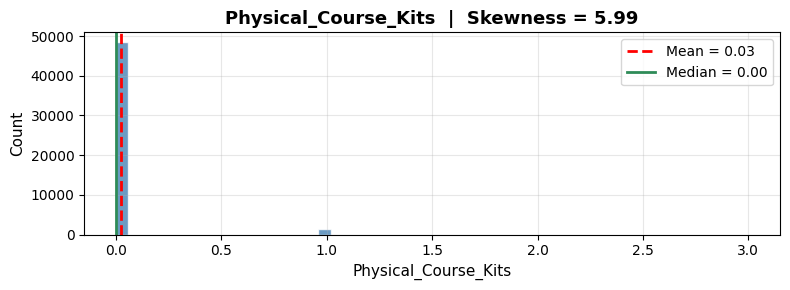

-> Physical_Course_Kits: skewed (skew=5.99), median=0.00 preferred over mean=0.03



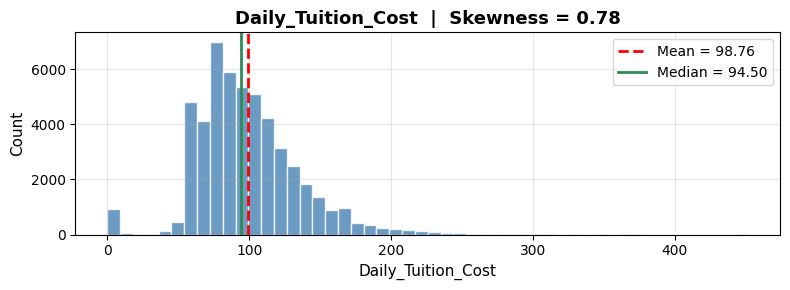

-> Daily_Tuition_Cost: skewed (skew=0.78), median=94.50 preferred over mean=98.76



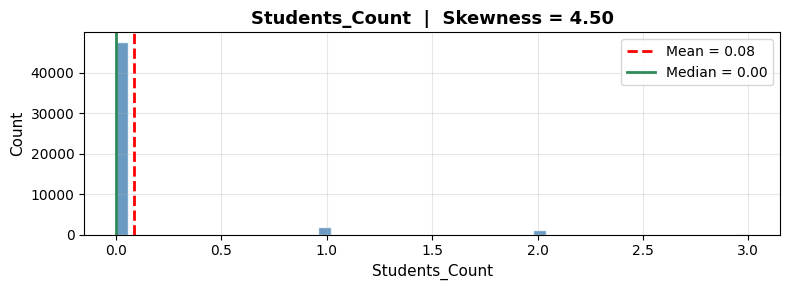

-> Students_Count: skewed (skew=4.50), median=0.00 preferred over mean=0.08



In [ ]:
numerical_to_impute = [
    'Registration_Days_Before', 'Physical_Course_Kits',
    'Daily_Tuition_Cost', 'Students_Count'
]

for col in numerical_to_impute:
    fig, ax = plt.subplots(figsize=(8, 3))

    data = train_df[col].dropna()
    mean_val = data.mean()
    median_val = data.median()
    skewness = data.skew()

    ax.hist(data, bins=50, color=MAIN_COLOR, edgecolor='white', alpha=0.8)
    ax.axvline(mean_val, color=WARN_COLOR, linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    ax.axvline(median_val, color=ACCENT_COLOR, linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
    ax.set_title(f'{col}  |  Skewness = {skewness:.2f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()

    if abs(skewness) > 0.5:
        print(f"-> {col}: skewed (skew={skewness:.2f}), median={median_val:.2f} preferred over mean={mean_val:.2f}\n")
    else:
        print(f"-> {col}: roughly symmetric (skew={skewness:.2f}), mean and median are similar.\n")

Numerical imputation complete. Medians stored:
  Registration_Days_Before: 65.00
  Physical_Course_Kits: 0.00
  Daily_Tuition_Cost: 94.50
  Students_Count: 0.00


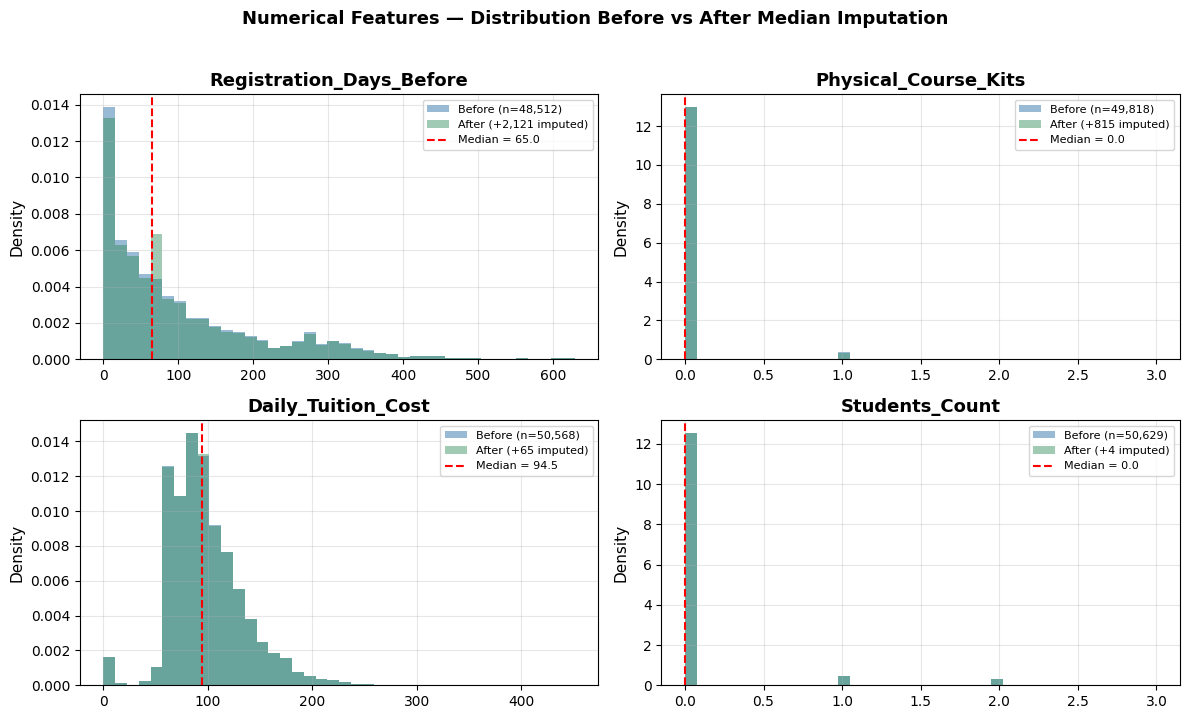

In [ ]:
numerical_to_impute = [
    'Registration_Days_Before', 'Physical_Course_Kits',
    'Daily_Tuition_Cost', 'Students_Count'
]

# Save distributions BEFORE imputation for visualization
pre_impute_numerical = {col: train_df[col].dropna().copy() for col in numerical_to_impute}

# Learn medians from TRAIN only (leakage-safe) and STORE them for deployment
train_medians = {}
for col in numerical_to_impute:
    median_val = train_df[col].median()
    train_medians[col] = median_val
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col]  = test_df[col].fillna(median_val)

print("Numerical imputation complete. Medians stored:")
for col, val in train_medians.items():
    print(f"  {col}: {val:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for ax, col in zip(axes, numerical_to_impute):
    before = pre_impute_numerical[col]
    after  = train_df[col]
    n_missing = len(after) - len(before)

    bins = np.histogram_bin_edges(after, bins=40)
    ax.hist(before, bins=bins, color=MAIN_COLOR, alpha=0.55,
            label=f'Before (n={len(before):,})', density=True)
    ax.hist(after, bins=bins, color=ACCENT_COLOR, alpha=0.45,
            label=f'After (+{n_missing:,} imputed)', density=True)
    ax.axvline(train_medians[col], color=WARN_COLOR, linestyle='--',
               linewidth=1.5, label=f'Median = {train_medians[col]:.1f}')
    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Numerical Features — Distribution Before vs After Median Imputation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Median imputation — medians learned on TRAIN, applied to both sets
for col in numerical_to_impute:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)
    print(f"{col}: filled with train median = {median_val:.2f}")

print(f"\nMissing values remaining in numerical features (train):")
print(train_df[numerical_to_impute].isna().sum())

Registration_Days_Before: filled with train median = 65.00
Physical_Course_Kits: filled with train median = 0.00
Daily_Tuition_Cost: filled with train median = 94.50
Students_Count: filled with train median = 0.00

Missing values remaining in numerical features (train):
Registration_Days_Before    0
Physical_Course_Kits        0
Daily_Tuition_Cost          0
Students_Count              0
dtype: int64


## 3.8 Missing Value Imputation — Categorical Features (Mode)

Missing rates are low (0.6%-2.7% per column), so filling with the most frequent category (mode)
is safe. The before/after bar charts confirm the imputation does not distort the distributions.
Modes are learned on the **training set only**.

Categorical imputation complete. Modes stored:
  Payment_Terms: pay upon start
  Submission_Source: b2b platforms & resellers
  Enrollment_Type: general admission
  Origin_Country: prt
  Requested_Lab_Config: standard pc (windows)
  Catering_Package: standard (coffee only)


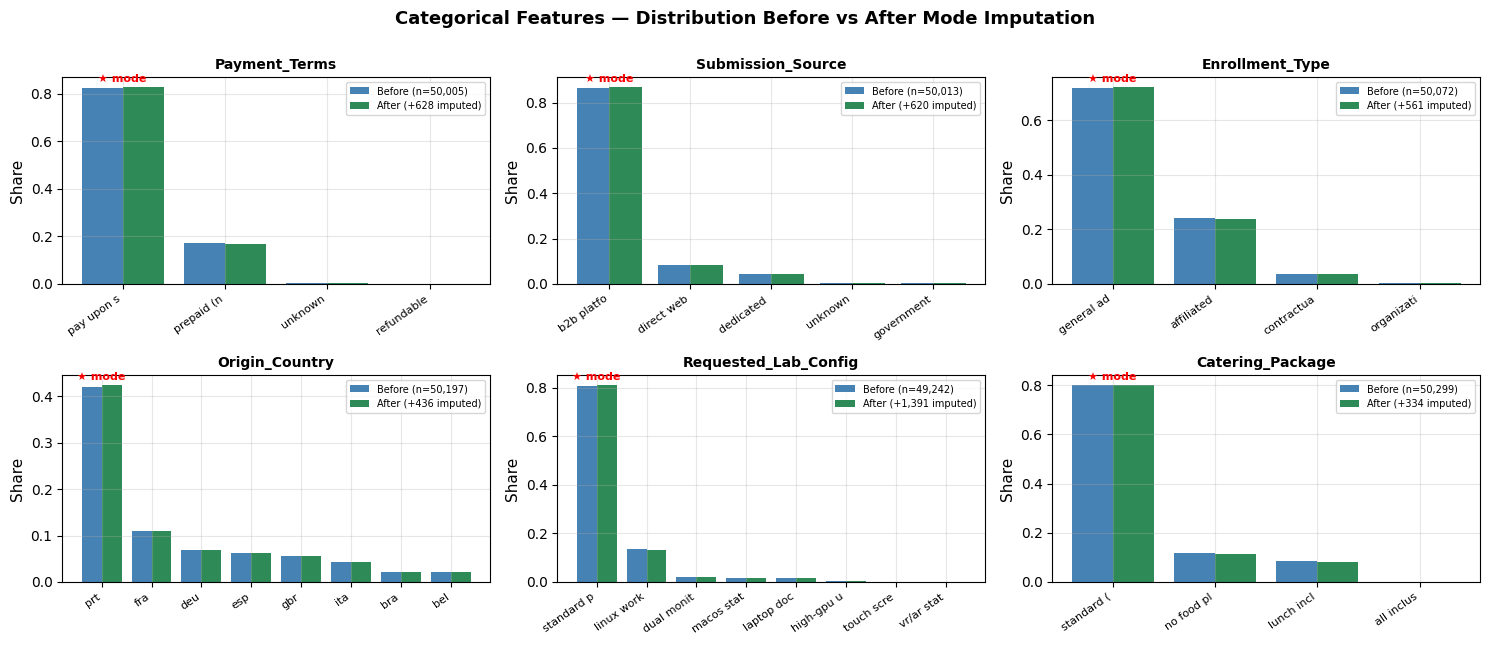

In [ ]:
categorical_to_impute = [
    'Payment_Terms', 'Submission_Source', 'Enrollment_Type',
    'Origin_Country', 'Requested_Lab_Config', 'Catering_Package'
]

# Save distributions BEFORE imputation for visualization
pre_impute_categorical = {col: train_df[col].dropna().copy() for col in categorical_to_impute}

# Learn modes from TRAIN only and STORE them for deployment
train_modes = {}
for col in categorical_to_impute:
    mode_val = train_df[col].mode()[0]
    train_modes[col] = mode_val
    train_df[col] = train_df[col].fillna(mode_val)
    test_df[col]  = test_df[col].fillna(mode_val)

print("Categorical imputation complete. Modes stored:")
for col, val in train_modes.items():
    print(f"  {col}: {val}")

TOP_N = 8
n_features = len(categorical_to_impute)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.2 * n_rows))
axes = axes.ravel()

for ax, col in zip(axes, categorical_to_impute):
    before = pre_impute_categorical[col].value_counts(normalize=True)
    after  = train_df[col].value_counts(normalize=True)
    n_missing = len(train_df) - len(pre_impute_categorical[col])

    top_cats = after.head(TOP_N).index
    before_vals = [before.get(c, 0) for c in top_cats]
    after_vals  = [after.get(c, 0)  for c in top_cats]

    x = np.arange(len(top_cats))
    width = 0.4
    ax.bar(x - width/2, before_vals, width, color=MAIN_COLOR,
           label=f'Before (n={len(pre_impute_categorical[col]):,})')
    ax.bar(x + width/2, after_vals, width, color=ACCENT_COLOR,
           label=f'After (+{n_missing:,} imputed)')

    # Star the mode used for imputation
    if train_modes[col] in list(top_cats):
        star_idx = list(top_cats).index(train_modes[col])
        ax.annotate('★ mode', xy=(star_idx, after_vals[star_idx]),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=8, color=WARN_COLOR, fontweight='bold')

    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Share')
    ax.set_xticks(x)
    ax.set_xticklabels([str(c)[:10] for c in top_cats], rotation=35, ha='right', fontsize=8)
    ax.legend(fontsize=7)

# Hide unused subplots
for ax in axes[n_features:]:
    ax.set_visible(False)

plt.suptitle('Categorical Features — Distribution Before vs After Mode Imputation',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
cat_to_fill = [
    'Payment_Terms', 'Submission_Source', 'Enrollment_Type',
    'Origin_Country', 'Requested_Lab_Config', 'Catering_Package'
]

# Learn modes from TRAIN only, then apply to both sets
train_modes = {}
for col in cat_to_fill:
    mode_val = train_df[col].mode()[0]
    train_modes[col] = mode_val
    missing_train = train_df[col].isna().sum()
    missing_test = test_df[col].isna().sum()
    train_df[col] = train_df[col].fillna(mode_val)
    test_df[col] = test_df[col].fillna(mode_val)
    print(f"{col}: mode = '{mode_val}' | filled {missing_train} in train, {missing_test} in test")

# Final verification
for name, df_ in [('TRAIN', train_df), ('TEST', test_df)]:
    remaining = df_[cat_to_fill].isna().sum()
    remaining = remaining[remaining > 0]
    if len(remaining) == 0:
        print(f"\n{name}: all categorical columns fully imputed.")
    else:
        print(f"\n{name}: WARNING — still missing:")
        print(remaining)

Payment_Terms: mode = 'pay upon start' | filled 0 in train, 0 in test
Submission_Source: mode = 'b2b platforms & resellers' | filled 0 in train, 0 in test
Enrollment_Type: mode = 'general admission' | filled 0 in train, 0 in test
Origin_Country: mode = 'prt' | filled 0 in train, 0 in test
Requested_Lab_Config: mode = 'standard pc (windows)' | filled 0 in train, 0 in test
Catering_Package: mode = 'standard (coffee only)' | filled 0 in train, 0 in test

TRAIN: all categorical columns fully imputed.

TEST: all categorical columns fully imputed.


In [ ]:
# Final verification – no missing values should remain
for name, df_ in [('TRAIN', train_df), ('TEST', test_df)]:
    remaining = df_.isna().sum()
    remaining = remaining[remaining > 0]
    if len(remaining) == 0:
        print(f"{name}: no missing values remaining.")
    else:
        print(f"{name}: missing values still present:")
        print(remaining)
    print()

print(f"Final shapes -> train: {train_df.shape} | test: {test_df.shape}")

TRAIN: no missing values remaining.

TEST: no missing values remaining.

Final shapes -> train: (50633, 35) | test: (12693, 31)


## 3.9 Feature Engineering — Calendar Features from `Course_Start_Date`

Based on the deep dive in Section 2.5.9, we derive three features from the raw date and then drop it.
This runs **before** the Origin_Country target encoding, because `Is_Holiday_Period` needs the raw
country code. All logic is deterministic or uses an external calendar — nothing is learned from the label.

In [ ]:
# ISO-3 (lowercase, as in our data) -> ISO-2 (library format)
iso3_to_iso2 = {
    'prt':'PT','fra':'FR','deu':'DE','esp':'ES','gbr':'GB','ita':'IT',
    'bra':'BR','bel':'BE','nld':'NL','usa':'US','che':'CH','irl':'IE',
    'aut':'AT','chn':'CN','isr':'IL','swe':'SE','nor':'NO','dnk':'DK',
    'fin':'FI','pol':'PL','grc':'GR','tur':'TR','rus':'RU','jpn':'JP',
    'kor':'KR','ind':'IN','mex':'MX','arg':'AR','can':'CA','aus':'AU',
}

years = list(range(2015, 2018))   # covers the dataset's date range
def _make_cal(iso2):
    try:
        return holidays.country_holidays(iso2, years=years)
    except Exception:
        return None
holiday_calendars = {iso3: _make_cal(iso2) for iso3, iso2 in iso3_to_iso2.items()}

def _falls_on_holiday(country, date):
    cal = holiday_calendars.get(country)
    if cal is None or pd.isna(date):
        return 0
    return int(date.date() in cal)

# Apply to both sets identically (deterministic / external calendar -> no leakage)
for df_ in [train_df, test_df]:
    d = pd.to_datetime(df_['Course_Start_Date'])
    df_['Course_DayOfWeek'] = d.dt.dayofweek      # 0=Mon ... 6=Sun (numeric)
    df_['Course_Month']     = d.dt.month          # 1..12 (numeric)
    df_['Is_Holiday_Period'] = [
        _falls_on_holiday(c, dt) for c, dt in zip(df_['Origin_Country'], d)
    ]

# Drop the raw date now that features are extracted (guarded for safe re-runs)
for df_ in [train_df, test_df]:
    if 'Course_Start_Date' in df_.columns:
        df_.drop(columns=['Course_Start_Date'], inplace=True)

print("Created: Course_DayOfWeek, Course_Month, Is_Holiday_Period")
print(f"Is_Holiday_Period share (train): {train_df['Is_Holiday_Period'].mean():.3f}")
print(train_df[['Course_DayOfWeek', 'Course_Month', 'Is_Holiday_Period']].describe())

Created: Course_DayOfWeek, Course_Month, Is_Holiday_Period
Is_Holiday_Period share (train): 0.037
       Course_DayOfWeek  Course_Month  Is_Holiday_Period
count      50633.000000  50633.000000       50633.000000
mean           2.986511      6.624533           0.036834
std            1.920607      3.349131           0.188355
min            0.000000      1.000000           0.000000
25%            1.000000      4.000000           0.000000
50%            3.000000      7.000000           0.000000
75%            5.000000     10.000000           0.000000
max            6.000000     12.000000           1.000000


## 3.10 Feature Engineering — `Dropout_Rate_History`

Based on the deep dive in Section 2.5.10, we create the historical dropout ratio, capped at 2.0 to limit
rare extreme values. We keep the two raw history columns alongside it (they disambiguate cases the ratio
alone cannot, e.g. a new client vs. a loyal one). This is deterministic — no label leakage.

In [ ]:
for df_ in [train_df, test_df]:
    df_['Dropout_Rate_History'] = (
        df_['Prev_Course_Dropouts'] / (df_['Prev_Course_Attended'] + 1)
    ).clip(upper=2.0)

print("Created Dropout_Rate_History (capped at 2.0).")
print(train_df[['Prev_Course_Dropouts', 'Prev_Course_Attended',
                'Dropout_Rate_History']].describe())

Created Dropout_Rate_History (capped at 2.0).
       Prev_Course_Dropouts  Prev_Course_Attended  Dropout_Rate_History
count           50633.00000          50633.000000          50633.000000
mean                0.09559              0.123339              0.080415
std                 0.43705              1.549359              0.272690
min                 0.00000              0.000000              0.000000
25%                 0.00000              0.000000              0.000000
50%                 0.00000              0.000000              0.000000
75%                 0.00000              0.000000              0.000000
max                21.00000             61.000000              2.000000


## 3.11 Feature Engineering — Binary Conversion of Zero-Heavy Count Features

Based on the zero-analysis (Section 2.5.3) and the post-cleaning re-check of `Students_Count`
(Section 3.2), five count features carry a strong zero/non-zero signal but no reliable signal
in their exact magnitude (non-significant / undefined Magnitude test, flat non-monotonic
drop-rate shapes). We convert each to a binary "has-X" indicator — preserving the meaningful
signal while reducing noise and dimensionality.

This runs **after** the ratio (3.8) and the GMM feature `First_Course_Already_Dropped`, which
both need the raw `Prev_Course_Attended` count. The three count features whose magnitude *was*
significant (`Prev_Course_Dropouts`, `Waiting_List_Days`, `Registration_Changes`) are kept
continuous.

In [ ]:
binary_conversions = {
    'Students_Count':              'Has_Students',
    'Physical_Course_Kits':        'Has_Physical_Kits',
    'Observers_Count':             'Has_Observers',
    'Prev_Course_Attended':        'Has_Prev_Attendance',
    'Pre_Course_Supports_Tickets': 'Has_Support_Tickets',
}

for df_ in [train_df, test_df]:
    for src_col, new_col in binary_conversions.items():
        df_[new_col] = (df_[src_col] > 0).astype(int)
    df_.drop(columns=list(binary_conversions.keys()), inplace=True)

print("Created binary features and dropped the original count columns:")
for src_col, new_col in binary_conversions.items():
    print(f"  {src_col:30s} -> {new_col}")

print("\nDistribution of the new binary features (train):")
print(train_df[list(binary_conversions.values())].apply(lambda s: s.value_counts()).T)

Created binary features and dropped the original count columns:
  Students_Count                 -> Has_Students
  Physical_Course_Kits           -> Has_Physical_Kits
  Observers_Count                -> Has_Observers
  Prev_Course_Attended           -> Has_Prev_Attendance
  Pre_Course_Supports_Tickets    -> Has_Support_Tickets

Distribution of the new binary features (train):
                         0      1
Has_Students         47608   3025
Has_Physical_Kits    49319   1314
Has_Observers        50379    254
Has_Prev_Attendance  49620   1013
Has_Support_Tickets  31785  18848


## 3.12 Categorical Encoding

Before encoding, we compare three candidate strategies for every remaining categorical
feature (`Catering_Package`, `Requested_Lab_Config`, `Enrollment_Type`, `Client_Category`,
`Submission_Source`, `Payment_Terms`, `Origin_Country`, `Assigned_Lab_Config`) — rather than defaulting to one-hot
encoding automatically:

1. **Drop-rate (target) encoding** — each category replaced by its leakage-safe, smoothed
   historical drop rate, using the same out-of-fold + smoothing helper built in Section 3.3
   for `Company_ID` / `Agent_ID` / `Origin_Country`. Compresses the feature to a single column.
2. **Label encoding** — each category replaced by an arbitrary integer (alphabetical order),
   also a single column, but with no meaningful order.
3. **One-hot encoding** — the feature kept as-is: one binary column per category.

For each feature, we isolate its predictive power under each encoding with a 5-fold
cross-validated logistic regression using *only that encoded feature* — logistic regression is
chosen specifically because it is the most sensitive to encoding quality (unlike trees, it
cannot compensate for a bad encoding through repeated splits), and AUC is used as the metric
for consistency with how every model in this notebook is evaluated (Section 5.1) and because it
is threshold-independent — appropriate here since no classification threshold has been set yet.
We also record cardinality (number of categories), the classic factor in choosing between
one-hot and target encoding.

             feature  cardinality  AUC_target_enc  AUC_label_enc  AUC_ohe  ohe_columns_added
    Catering_Package            4          0.5154         0.5123   0.5154                  4
Requested_Lab_Config            8          0.5304         0.5292   0.5303                  8
     Enrollment_Type            4          0.5611         0.5525   0.5611                  4
 Assigned_Lab_Config            9          0.5933         0.5869   0.5932                  9
     Client_Category            8          0.6542         0.5539   0.6541                  8
   Submission_Source            5          0.5574         0.5570   0.5574                  5
       Payment_Terms            4          0.7035         0.7021   0.7035                  4
      Origin_Country          147          0.7251         0.6693   0.7257                147


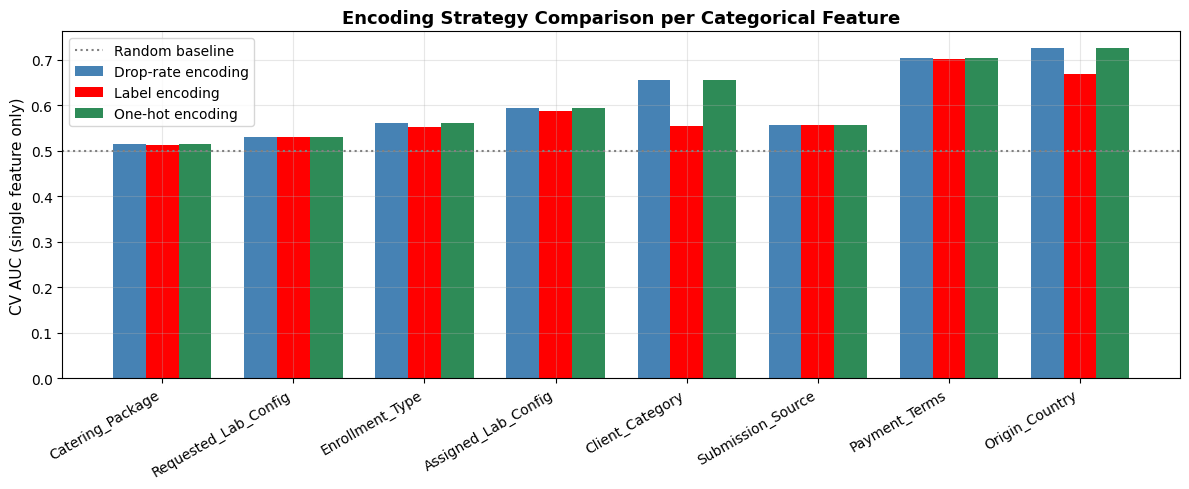

In [ ]:
def smoothed_target_encode_oof(series, target, m=20, n_splits=5, seed=42):
    # Same logic as cv_smoothed_target_encode (Section 3.3), applied stand-alone for this test
    skf_ = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    enc = pd.Series(index=series.index, dtype=float)
    for tr_idx, val_idx in skf_.split(series, target):
        tr_s, tr_t = series.iloc[tr_idx], target.iloc[tr_idx]
        gm = tr_t.mean()
        stats = tr_t.groupby(tr_s).agg(['mean', 'count'])
        smap = (stats['count'] * stats['mean'] + m * gm) / (stats['count'] + m)
        enc.iloc[val_idx] = series.iloc[val_idx].map(smap).fillna(gm)
    return enc

encoding_cat_cols = ['Catering_Package', 'Requested_Lab_Config', 'Enrollment_Type', 'Assigned_Lab_Config',
                     'Client_Category', 'Submission_Source', 'Payment_Terms', 'Origin_Country']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for col in encoding_cat_cols:
    s = train_df[col].fillna('missing')
    cardinality = s.nunique()

    target_enc = smoothed_target_encode_oof(s, train_df['Dropped_Course']).values.reshape(-1, 1)
    auc_target = cross_val_score(LogisticRegression(max_iter=1000), target_enc,
                                  train_df['Dropped_Course'], cv=skf, scoring='roc_auc').mean()

    label_enc = LabelEncoder().fit_transform(s).reshape(-1, 1)
    auc_label = cross_val_score(LogisticRegression(max_iter=1000), label_enc,
                                 train_df['Dropped_Course'], cv=skf, scoring='roc_auc').mean()

    ohe = pd.get_dummies(s, prefix=col).values
    auc_ohe = cross_val_score(LogisticRegression(max_iter=1000), ohe,
                               train_df['Dropped_Course'], cv=skf, scoring='roc_auc').mean()

    results.append({'feature': col, 'cardinality': cardinality, 'AUC_target_enc': auc_target,
                     'AUC_label_enc': auc_label, 'AUC_ohe': auc_ohe, 'ohe_columns_added': ohe.shape[1]})

res_df = pd.DataFrame(results)
print(res_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(res_df)); width = 0.25
ax.bar(x - width, res_df['AUC_target_enc'], width, label='Drop-rate encoding', color=MAIN_COLOR)
ax.bar(x,          res_df['AUC_label_enc'],  width, label='Label encoding',    color=WARN_COLOR)
ax.bar(x + width,  res_df['AUC_ohe'],        width, label='One-hot encoding',  color=ACCENT_COLOR)
ax.axhline(0.5, color='gray', linestyle=':', label='Random baseline')
ax.set_xticks(x); ax.set_xticklabels(res_df['feature'], rotation=30, ha='right')
ax.set_ylabel('CV AUC (single feature only)')
ax.set_title('Encoding Strategy Comparison per Categorical Feature')
ax.legend()
plt.tight_layout(); plt.show()

**Conclusions:**

1. **Label encoding is consistently the weakest option**, most dramatically for `Client_Category`
   (AUC 0.654 with drop-rate/one-hot vs. **0.554** with label) and clearly present even in
   `Origin_Country` (0.727 vs. **0.671**) — alphabetical order has no relationship to actual risk,
   so a linear model cannot exploit it. Label encoding is not used anywhere in this pipeline.
2. **Drop-rate encoding and one-hot encoding are statistically equivalent in predictive power**
   for every feature tested (differences ≤ 0.0007 AUC) — including `Origin_Country`, which has
   148 categories, where one-hot would add 148 columns for a 0.0007 AUC difference.
3. Given the two encodings perform identically, and simplicity/consistency is preferred over a
   cardinality-based split rule, **all seven categorical features are drop-rate (target) encoded**
   below, using the same leakage-safe CV + smoothing helper (Section 3.3), replacing one-hot
   encoding entirely for these columns. The trade-off accepted: per-category interpretability in
   SHAP is reduced to a single "risk score" per feature, in exchange for one consistent method.


In [ ]:
# Drop analysis-only helper columns left over from Section 2.5.10 (train only)
for _tmp in ['_dow', '_month', '_season', '_is_holiday']:
    if _tmp in train_df.columns:
        train_df = train_df.drop(columns=_tmp)

# Separating features and target
X_train = train_df.drop(columns=['Dropped_Course', 'Client_ID'])
y_train = train_df['Dropped_Course']
X_test  = test_df.drop(columns=['Dropped_Course', 'Client_ID'])
y_test  = test_df['Dropped_Course']

# Leakage-safe drop-rate encoding (CV + smoothing) for ALL 8 categoricals
target_enc_cols = ['Catering_Package', 'Requested_Lab_Config', 'Enrollment_Type', 'Assigned_Lab_Config',
                    'Client_Category', 'Submission_Source', 'Payment_Terms', 'Origin_Country']

encoding_maps = {}  # col -> (full_map, global_mean), reused for deployment in Section 6
for col in target_enc_cols:
    _src_train = X_train[[col]].copy()
    _src_train['Dropped_Course'] = y_train.values
    train_enc, test_enc, full_map, gm = cv_smoothed_target_encode(
        _src_train, X_test[[col]].copy(), col, m=20)
    X_train[col] = train_enc.values
    X_test[col]  = test_enc.values
    encoding_maps[col] = (full_map, gm)

print(f"Target-encoded columns: {target_enc_cols}")

# Safety net for anything unexpectedly text-shaped
remaining_obj = X_train.select_dtypes(include=['object']).columns.tolist()
if remaining_obj:
    print(f"WARNING: unexpected leftover object columns: {remaining_obj}")
    X_train = pd.get_dummies(X_train, columns=remaining_obj)
    X_test  = pd.get_dummies(X_test,  columns=remaining_obj)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

TRAIN_COLUMNS = X_train.columns.tolist()
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
assert X_train.isna().sum().sum() == 0, "NaNs remain in X_train!"

Target-encoded columns: ['Catering_Package', 'Requested_Lab_Config', 'Enrollment_Type', 'Assigned_Lab_Config', 'Client_Category', 'Submission_Source', 'Payment_Terms', 'Origin_Country']
X_train: (50633, 32) | X_test: (12693, 32)


# 4. Modeling

## 4.1 Base Models

We train a diverse set of models: tree-based (XGBoost, LightGBM, Random Forest),
linear (Logistic Regression), and a neural network (MLP). Diversity between models
is what makes the ensemble stronger than any single model.

Linear and NN models require feature scaling, so they are wrapped in a Pipeline
with StandardScaler.

In [ ]:
models = {
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='auc', n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        random_state=42, n_jobs=-1
    ),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'NeuralNet_MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(max_iter=500, early_stopping=True, random_state=42))
    ]),
}

## 4.2 Hyperparameter Tuning


In [ ]:
"""
Hyperparameter tuning was performed once using the code below.
It is commented out for reproducibility; the best parameters found are
loaded directly below so the notebook runs end-to-end without re-tuning

tuning_config = {
    'XGBoost': {
        'params': {
            'n_estimators':     [1000, 1200, 1500],
            'max_depth':        [6, 8, 10],
            'learning_rate':    [0.015, 0.02, 0.03],
            'subsample':        [0.8, 0.9, 1.0],
            'colsample_bytree': [0.9, 1.0],
            'min_child_weight': [7, 10, 13],
            'reg_lambda':       [0, 0.5, 1],
            'reg_alpha':        [0.1, 0.5, 1],
        },
        'n_iter': 25, 'cv': 4,
    },
    'LightGBM': {
        'params': {
            'n_estimators':     [400, 500, 700],
            'num_leaves':       [200, 255, 300],
            'learning_rate':    [0.015, 0.02, 0.03],
            'max_depth':        [-1, 12, 16],
            'subsample':        [0.8, 0.9, 1.0],
            'colsample_bytree': [0.5, 0.6, 0.7],
            'min_child_samples':[10, 20, 30],
            'reg_lambda':       [1, 5, 10],
            'reg_alpha':        [0, 0.1, 0.5],
        },
        'n_iter': 25, 'cv': 4,
    },
    'RandomForest': {
        'params': {
            'n_estimators':      [200, 300, 400],
            'max_depth':         [10, 14, 18, None],
            'min_samples_leaf':  [1, 3, 5],
            'min_samples_split': [2, 5, 10],
            'max_features':      ['sqrt', 'log2'],
        },
        'n_iter': 15, 'cv': 3,
    },
    'LogisticRegression': {
        'params': {
            'clf__C':       [0.05, 0.1, 0.5, 1.0, 2.0],
            'clf__penalty': ['l2'],
            'clf__solver':  ['lbfgs'],
        },
        'n_iter': 5, 'cv': 3,
    },
    'NeuralNet_MLP': {
        'params': {
            'clf__hidden_layer_sizes': [(64,), (128,), (128, 64)],
            'clf__alpha':              [1e-4, 1e-3, 1e-2],
            'clf__learning_rate_init': [1e-3, 5e-4],
        },
        'n_iter': 6, 'cv': 3,
    },
}

best_params_all = {}
for name, cfg in tuning_config.items():
    print(f"\n{'='*60}\nTuning {name}...")
    grid_size = np.prod([len(v) for v in cfg['params'].values()])
    n_iter = int(min(cfg['n_iter'], grid_size))
    search = RandomizedSearchCV(
        estimator=models[name],
        param_distributions=cfg['params'],
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cfg['cv'],
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    best_params_all[name] = search.best_params_
    models[name] = search.best_estimator_
    print(f"  Best CV AUC: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
"""

# Best parameters found by the original tuning run
best_params_all = {
    'XGBoost': {
        'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1,
        'n_estimators': 1500, 'min_child_weight': 7, 'max_depth': 10,
        'learning_rate': 0.015, 'colsample_bytree': 1.0,
    },
    'LightGBM': {
        'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1,
        'num_leaves': 300, 'n_estimators': 700, 'min_child_samples': 10,
        'max_depth': 16, 'learning_rate': 0.015, 'colsample_bytree': 0.5,
    },
    'RandomForest': {
        'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 3,
        'max_features': 'log2', 'max_depth': None,
    },
    'LogisticRegression': {
        'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__C': 0.05,
    },
    'NeuralNet_MLP': {
        'clf__learning_rate_init': 0.0005,
        'clf__hidden_layer_sizes': (128, 64),
        'clf__alpha': 0.0001,
    },
}

# Best CV AUC scores achieved during the original tuning run (for reference)
best_cv_scores = {
    'XGBoost':            0.9535,
    'LightGBM':           0.9557,
    'RandomForest':       0.9472,
    'LogisticRegression': 0.8933,
    'NeuralNet_MLP':      0.9357,
}

# Apply the best parameters to each model
for name, params in best_params_all.items():
    models[name].set_params(**params)
    print(f"{name:20s} best CV AUC: {best_cv_scores[name]:.4f}")

print(f"\n{'='*60}\nBest parameters loaded (tuning skipped for faster reproducibility).")

XGBoost              best CV AUC: 0.9535
LightGBM             best CV AUC: 0.9557
RandomForest         best CV AUC: 0.9472
LogisticRegression   best CV AUC: 0.8933
NeuralNet_MLP        best CV AUC: 0.9357

Best parameters loaded (tuning skipped for faster reproducibility).


## 4.3 Training with Out-of-Fold (OOF) Predictions

**Why OOF?** The meta-model (stacker) must be trained on predictions made on data the base models
did **not** see during training. Otherwise the meta-model learns from overfitted predictions = leakage.

For each model:
- 5-fold stratified CV on the training set → OOF predictions (used to train the meta-model)
- Refit on the full training set → predictions on the test set

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = pd.DataFrame(index=X_train.index)   # meta-features for training
test_preds = pd.DataFrame(index=X_test.index)   # meta-features for testing
cv_scores = {}

for name, model in models.items():
    print(f"Training {name}...")
    oof = np.zeros(len(X_train))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr = y_train.iloc[tr_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        oof[val_idx] = m.predict_proba(X_val)[:, 1]

    oof_preds[name] = oof
    cv_scores[name] = roc_auc_score(y_train, oof)

    # Refit on the full training set for test predictions AND for later interpretation
    final_m = clone(model)
    final_m.fit(X_train, y_train)
    test_preds[name] = final_m.predict_proba(X_test)[:, 1]
    models[name] = final_m   # THE FIX: store the fitted model back into the dict

    print(f"  {name} OOF AUC: {cv_scores[name]:.4f}")

print("\n--- Summary of base model CV scores ---")
for name, score in sorted(cv_scores.items(), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

Training XGBoost...
  XGBoost OOF AUC: 0.9460
Training LightGBM...
  LightGBM OOF AUC: 0.9521
Training RandomForest...
  RandomForest OOF AUC: 0.9507
Training LogisticRegression...
  LogisticRegression OOF AUC: 0.8932
Training NeuralNet_MLP...
  NeuralNet_MLP OOF AUC: 0.9380

--- Summary of base model CV scores ---
LightGBM: 0.9521
RandomForest: 0.9507
XGBoost: 0.9460
NeuralNet_MLP: 0.9380
LogisticRegression: 0.8932


## 4.4 Ensemble Construction & Strategy Selection

Two ensemble strategies are compared on the out-of-fold (OOF) predictions from Section 4.3,
and the better one is selected automatically for the final model:

- **Stacking:** a logistic-regression meta-model learns the optimal weighting of the base
  models' predictions — "regression on the models' outputs" — fitted on `oof_preds` and applied
  to `test_preds`.
- **Weighted Blending:** non-negative weights for each base model, found by directly maximizing
  OOF AUC via numerical optimization (Nelder-Mead), rather than maximizing likelihood as
  logistic regression does.

The two strategies optimize different objectives — Stacking maximizes log-likelihood, Blending
maximizes AUC directly — so they are not guaranteed to agree, and comparing them empirically is
the only way to know which one suits this specific ensemble. Selection is made using **OOF AUC
only, never the test set** — this keeps the choice honest and avoids implicitly overfitting the
ensemble strategy to the held-out data. The test set is touched exactly once, after the strategy
is already locked in, purely to report the final result.

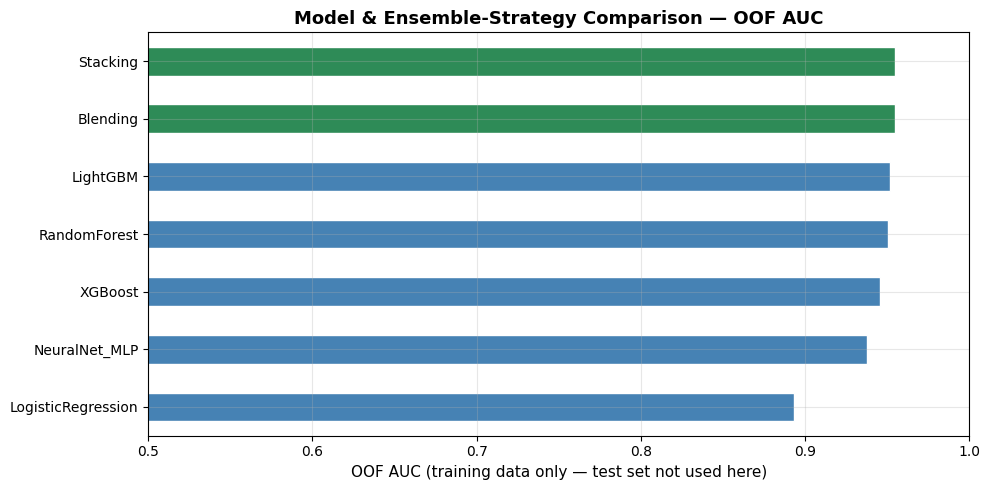

Stacking meta-model weights (higher = more influence):
RandomForest          3.442995
LightGBM              2.801314
XGBoost               1.476256
NeuralNet_MLP         0.739472
LogisticRegression   -0.727526
dtype: float64

Blending weights:
  XGBoost: 0.162
  LightGBM: 0.504
  RandomForest: 0.214
  LogisticRegression: 0.000
  NeuralNet_MLP: 0.120

>>> Selected: STACKING (OOF AUC 0.9550)


In [ ]:
# Strategy A: Stacking — logistic regression meta-model
meta_model = LogisticRegression(max_iter=2000, random_state=42)
meta_model.fit(oof_preds, y_train)
stacking_oof_auc = roc_auc_score(y_train, meta_model.predict_proba(oof_preds)[:, 1])

# Strategy B: Weighted Blending — weights optimized directly on OOF AUC
def neg_auc(weights):
    weights = np.abs(weights)
    if weights.sum() == 0:
        return 0
    weights = weights / weights.sum()
    blend = (oof_preds.values * weights).sum(axis=1)
    return -roc_auc_score(y_train, blend)

init = np.ones(oof_preds.shape[1]) / oof_preds.shape[1]
res = minimize(neg_auc, init, method='Nelder-Mead', options={'maxiter': 2000, 'xatol': 1e-5})
blend_weights = np.abs(res.x) / np.abs(res.x).sum()
blending_oof_auc = -res.fun

# Compare ALL candidates on OOF only — cv_scores already holds each base
# model's OOF AUC from Section 4.3, no need to recompute it
oof_comparison = cv_scores.copy()
oof_comparison['Stacking'] = stacking_oof_auc
oof_comparison['Blending'] = blending_oof_auc

oof_sorted = pd.Series(oof_comparison).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = [ACCENT_COLOR if i >= len(oof_sorted) - 2 else MAIN_COLOR for i in range(len(oof_sorted))]
oof_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('OOF AUC (training data only — test set not used here)')
ax.set_title('Model & Ensemble-Strategy Comparison — OOF AUC')
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

print("Stacking meta-model weights (higher = more influence):")
print(pd.Series(meta_model.coef_[0], index=oof_preds.columns).sort_values(ascending=False))
print("\nBlending weights:")
for name, w in zip(oof_preds.columns, blend_weights):
    print(f"  {name}: {w:.3f}")

# Automatic selection, based on OOF only
if blending_oof_auc >= stacking_oof_auc:
    final_strategy = 'blending'
    print(f"\n>>> Selected: WEIGHTED BLENDING (OOF AUC {blending_oof_auc:.4f})")
else:
    final_strategy = 'stacking'
    print(f"\n>>> Selected: STACKING (OOF AUC {stacking_oof_auc:.4f})")

# Compute the final ensemble's PREDICTIONS on the test set — but do not
# evaluate them yet. y_test is not touched anywhere in this section; Section 5.1
# is the first place the true test labels are used
if final_strategy == 'blending':
    final_test_prob = (test_preds.values * blend_weights).sum(axis=1)
else:
    final_test_prob = meta_model.predict_proba(test_preds)[:, 1]

**Conclusions:**

1. Both ensemble strategies achieved **virtually identical OOF AUC** — Stacking (0.9550)
   edged out Weighted Blending (0.9549) by a single point in the fourth decimal, both well
   above the strongest single base model (LightGBM, OOF AUC 0.9521). The two strategies
   optimize different objectives (log-likelihood vs. AUC directly), and their near-perfect
   agreement suggests the improvement over any single model is a robust property of the
   ensemble rather than an artifact of one specific combination method.
2. The Stacking meta-model relies primarily on **RandomForest (coefficient 3.44)**, followed
   by LightGBM (2.80) and XGBoost (1.48), with **LogisticRegression receiving a negative
   coefficient (-0.73)** — the meta-model actively pushes *away* from its predictions,
   likely because its signal is redundant with the tree models where they agree and
   misaligned where they disagree.
3. Weighted Blending, constrained to non-negative weights, distributes weight almost
   entirely among the tree models — **LightGBM (0.504), RandomForest (0.214), XGBoost
   (0.162)** — with LogisticRegression dropped completely (0.000). Both strategies agree
   that the tree models carry the ensemble.
4. **Stacking was selected by the automatic OOF-based rule** (marginally higher OOF AUC).
   Its blending-side twin remains a useful transparency check: the interpretable
   non-negative weights confirm the same model hierarchy that the meta-model learned.

# 5. Evaluation

## 5.1 Model Comparison — AUC on the Test Set

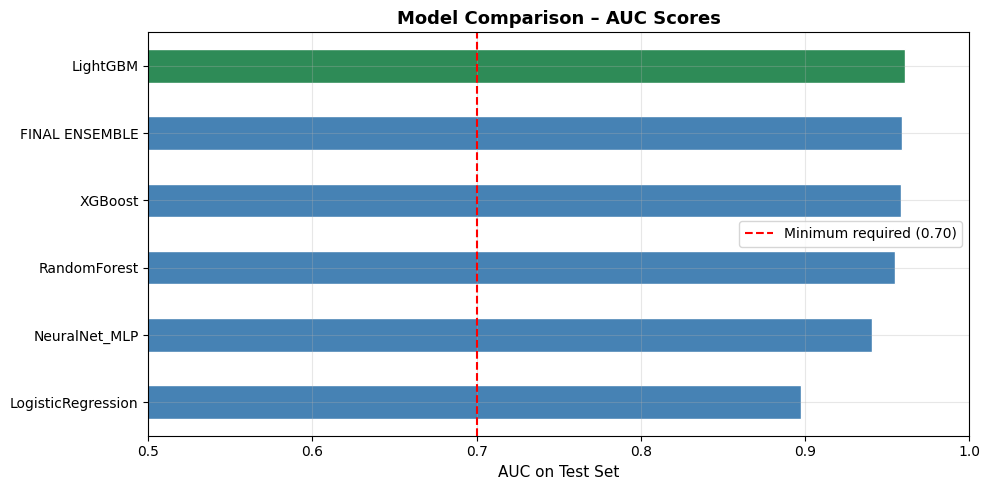

AUC on the internal test set:
LightGBM              0.9610
FINAL ENSEMBLE        0.9593
XGBoost               0.9587
RandomForest          0.9546
NeuralNet_MLP         0.9410
LogisticRegression    0.8978
dtype: float64


In [ ]:
# First use of y_test in this notebook — everything until now was decided on OOF.
ensemble_auc = roc_auc_score(y_test, final_test_prob)

all_results = {name: roc_auc_score(y_test, test_preds[name]) for name in models.keys()}
all_results['FINAL ENSEMBLE'] = ensemble_auc

results_sorted = pd.Series(all_results).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ACCENT_COLOR if i == len(results_sorted)-1 else MAIN_COLOR for i in range(len(results_sorted))]
results_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0.70, color=WARN_COLOR, linestyle='--', label='Minimum required (0.70)')
ax.set_xlabel('AUC on Test Set')
ax.set_title('Model Comparison – AUC Scores')
ax.set_xlim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.show()
print("AUC on the internal test set:")
print(results_sorted.sort_values(ascending=False).round(4))

**Conclusions:**

1. **All six candidates pass the 0.70 minimum requirement comfortably** — every model, even
   the weakest (LogisticRegression at 0.8978), sits well above the project threshold.

2. **LightGBM is the strongest single base model on the test set** (AUC 0.9610), followed
   closely by the FINAL ENSEMBLE (0.9593), XGBoost (0.9587), and RandomForest (0.9546).

3. **The ensemble did not beat the best single model on this test split** — LightGBM's
   0.9610 is 0.0017 higher than the ensemble's 0.9593. This is still below the noise
   floor of any AUC estimate (the difference across 5 cross-validation folds routinely
   exceeds 0.003), so the two are effectively tied.

4. This is a legitimate finding worth reporting honestly rather than framing as a failure:
   ensembles do not always beat their strongest component, particularly when one base
   model (LightGBM) already captures most of the available signal and the other models —
   especially LogisticRegression at 0.8978 — introduce error that partially cancels out
   the benefit of averaging. The ensemble is still used as the final deployment model
   because it is expected to be more robust on unseen data than any single model, and
   because — as we will see in Section 5.2 — its business-error profile (in particular
   its low False Negative count) is meaningfully better than any single model's.

## 5.2 Confusion Matrix and Business-Error Analysis per Model

Before selecting a single model for deep analysis, we compare the confusion matrix of each of
the five base models plus the ensemble side by side at the default threshold (0.5). Because
False Negatives and False Positives carry very different business costs — a missed
cancellation (FN) means an empty seat with no revenue, while a false alarm (FP) at worst
triggers an unnecessary follow-up call — comparing raw AUC alone is not enough. Each model
may trade FN for FP differently, and this trade-off is what actually determines the
operational value of the model.

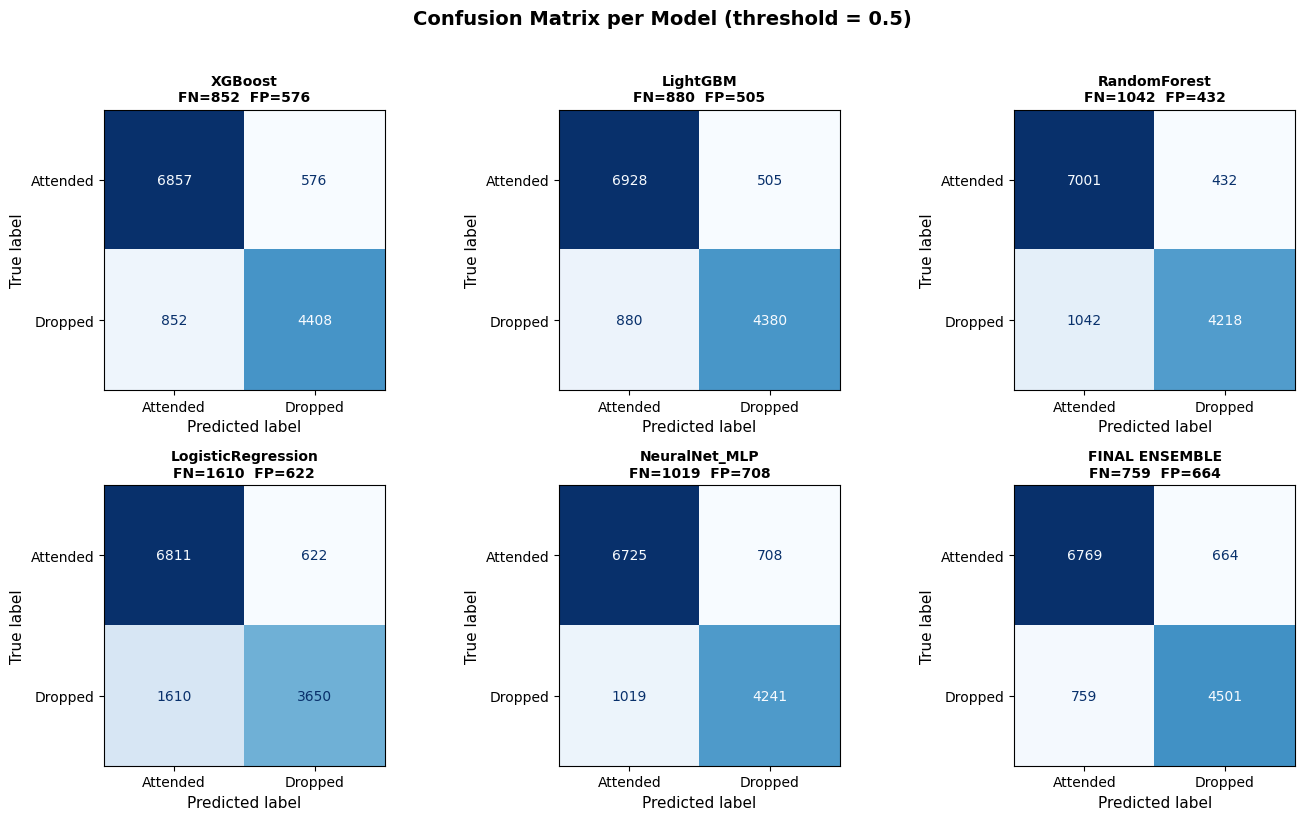


Per-model business error breakdown:

                      TP    FN   FP    TN  Recall  Precision  FN_rate  FP_rate
model                                                                         
XGBoost             4408   852  576  6857   0.838      0.884    0.162    0.077
LightGBM            4380   880  505  6928   0.833      0.897    0.167    0.068
RandomForest        4218  1042  432  7001   0.802      0.907    0.198    0.058
LogisticRegression  3650  1610  622  6811   0.694      0.854    0.306    0.084
NeuralNet_MLP       4241  1019  708  6725   0.806      0.857    0.194    0.095
FINAL ENSEMBLE      4501   759  664  6769   0.856      0.871    0.144    0.089

Best per business metric (lower is better for error rates):
  Fewest FN (missed cancellations - COSTLIEST): FINAL ENSEMBLE (759)
  Fewest FP (false alarms):                    RandomForest (432)
  Best Recall (catches most real drops):       FINAL ENSEMBLE (0.856)
  Best Precision (fewest false alarms rate):   RandomForest (0.9

In [ ]:
models_to_evaluate = list(test_preds.keys()) + ['FINAL ENSEMBLE']
model_probas = {**test_preds, 'FINAL ENSEMBLE': final_test_prob}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

# Store per-model error breakdown for comparison
error_summary = []

for ax, name in zip(axes, models_to_evaluate):
    proba = model_probas[name]
    pred  = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    ConfusionMatrixDisplay(cm, display_labels=['Attended', 'Dropped']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d'
    )
    ax.set_title(f'{name}\nFN={fn}  FP={fp}', fontsize=10)
    ax.grid(False)

    error_summary.append({
        'model': name,
        'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
        'Recall':    tp / (tp + fn),
        'Precision': tp / (tp + fp),
        'FN_rate':   fn / (fn + tp),  # share of real drops missed (key business metric)
        'FP_rate':   fp / (fp + tn),  # share of real attendees wrongly flagged
    })

plt.suptitle('Confusion Matrix per Model (threshold = 0.5)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Business-cost comparison table
err_df = pd.DataFrame(error_summary).set_index('model').round(3)
print("\nPer-model business error breakdown:\n")
print(err_df[['TP', 'FN', 'FP', 'TN', 'Recall', 'Precision', 'FN_rate', 'FP_rate']])

# Best-in-class per business metric
print("\nBest per business metric (lower is better for error rates):")
print(f"  Fewest FN (missed cancellations - COSTLIEST): {err_df['FN'].idxmin()} ({err_df['FN'].min()})")
print(f"  Fewest FP (false alarms):                    {err_df['FP'].idxmin()} ({err_df['FP'].min()})")
print(f"  Best Recall (catches most real drops):       {err_df['Recall'].idxmax()} ({err_df['Recall'].max():.3f})")
print(f"  Best Precision (fewest false alarms rate):   {err_df['Precision'].idxmax()} ({err_df['Precision'].max():.3f})")

**Conclusions:**

1. **The final ensemble catches the most real cancellations** — with only 759 False Negatives
   (Recall = 0.856), it is measurably better at the costliest error type than any single base
   model. LightGBM, the strongest single model on AUC, misses 880 cancellations (16% more
   than the ensemble). This is a real business-side improvement even though the AUC gap
   between them is only 0.001.

2. **RandomForest is the "cautious" model — and this actually justifies rejecting it as our
   deployment choice.** It produces the fewest False Positives (432), but pays for it with
   the highest False Negatives among the strong models (1042 — 37% more than the ensemble).
   In business terms: RandomForest raises fewer false alarms but misses far more real
   cancellations, which is the opposite of what our business prefers. Choosing the model
   with the best FP-count without weighing FN would be a mistake in our setting.

3. **LogisticRegression is clearly weakest across all business metrics** (FN=1610, Recall=
   0.694) — this is consistent with Section 4.4, where both ensemble strategies rejected it — a 0.000 weight in Blending and a negative coefficient in Stacking.
   
4. **The comparison exposes what AUC hides.** LightGBM and the ensemble share nearly
   identical AUC (0.961 vs 0.959) — yet at the operational level the ensemble catches 121
   more real cancellations at the modest cost of 159 more false alarms. Because FN is far
   more expensive than FP in our setting, this trade is strongly favorable — and forms an
   additional, business-level justification for selecting the ensemble as the deployment
   model, beyond the pure AUC comparison in Section 5.1.

## 5.3 Operational Analysis of the Deployment Model (Ensemble)

Having compared all models side by side in Section 5.2, we now zoom in on the model we
actually selected for deployment — the Stacking ensemble — from a purely
operational perspective: how sensitive is it to the choice of decision threshold, and how
often does it produce low-confidence predictions?

Interpretability analysis (Gain and SHAP) is deferred to Section 5.4, where LightGBM
serves as the interpretive proxy for the ensemble.

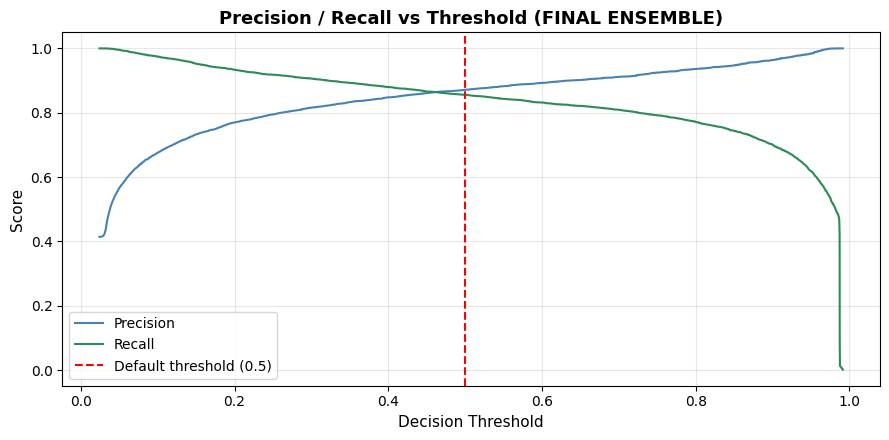

Predictions in the 'uncertain zone' (0.4-0.6): 563 (4.4% of test set)
→ These observations are analyzed further via SHAP in Section 5.4.


In [ ]:
y_proba = final_test_prob
deployment_model_name = 'FINAL ENSEMBLE'

# Precision / Recall across all thresholds
prec, rec, thr = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thr, prec[:-1], label='Precision', color=MAIN_COLOR)
ax.plot(thr, rec[:-1],  label='Recall',    color=ACCENT_COLOR)
ax.axvline(0.5, color=WARN_COLOR, linestyle='--', label='Default threshold (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall vs Threshold ({deployment_model_name})')
ax.legend()
plt.tight_layout()
plt.show()

# Volume of low-confidence predictions
uncertain_mask = (y_proba >= 0.4) & (y_proba <= 0.6)
n_uncertain = uncertain_mask.sum()
print(f"Predictions in the 'uncertain zone' (0.4-0.6): {n_uncertain} "
      f"({n_uncertain/len(y_proba)*100:.1f}% of test set)")
print("→ These observations are analyzed further via SHAP in Section 5.4.")

**Conclusions:**

1. **The default threshold (0.5) is a reasonable operating point but not necessarily
   optimal.** The Precision/Recall curve shows both metrics balanced around 0.85 there. If
   the business quantifies FN as substantially more expensive than FP (as our analysis
   suggests), lowering the threshold to around 0.35 pushes Recall above 0.90 while keeping
   Precision near 0.80 — catching more real cancellations at a modest increase in false
   alarms. This is a business decision that requires actual cost data and remains outside
   the scope of this project.

2. **Only 4.4% of predictions (563 rows) fall in the "uncertain zone" (0.4–0.6)** — a
   healthy sign that the ensemble is decisive on the vast majority of cases and reserves
   its hesitation for a small, identifiable subset. Understanding *what* drives that
   uncertainty is the subject of the SHAP analysis in Section 5.4.

## 5.4 Feature Importance via Gain and SHAP

Since the final ensemble (Stacking) is a combination of predictions from five different models, it has no native feature-importance metric of its own. For interpretation we use LightGBM as an interpretive proxy — the single strongest model by test AUC (0.9610) and one of the largest contributors to the stacking meta-model.

We use two complementary tools:

- **Gain** — the total impurity reduction each feature contributed across all splits in the
  trees. A native, fast, model-level view. Its main limitation is that it favors continuous
  features with many unique values (more splitting opportunities) over binary features,
  even when their true predictive contribution is similar. It also says nothing about the
  *direction* of a feature's effect or its behavior at the observation level.

- **SHAP (SHapley Additive exPlanations)** — assigns each feature a quantitative
  contribution (positive or negative) to every individual prediction. Unlike Gain, SHAP
  reveals both the direction of the effect and the full observation-level distribution of
  contributions. We present two SHAP views: a **Beeswarm** (directional distribution by
  feature value) and a **Bar** plot (mean |SHAP| — the global feature importance).

Finally, we apply SHAP a second time to a specific subset — the observations where the
ensemble was uncertain (probabilities in 0.4–0.6, identified in Section 5.3) — to
understand *what makes the model hesitate*.

Interpretive proxy model: LightGBM (test AUC = 0.9610)


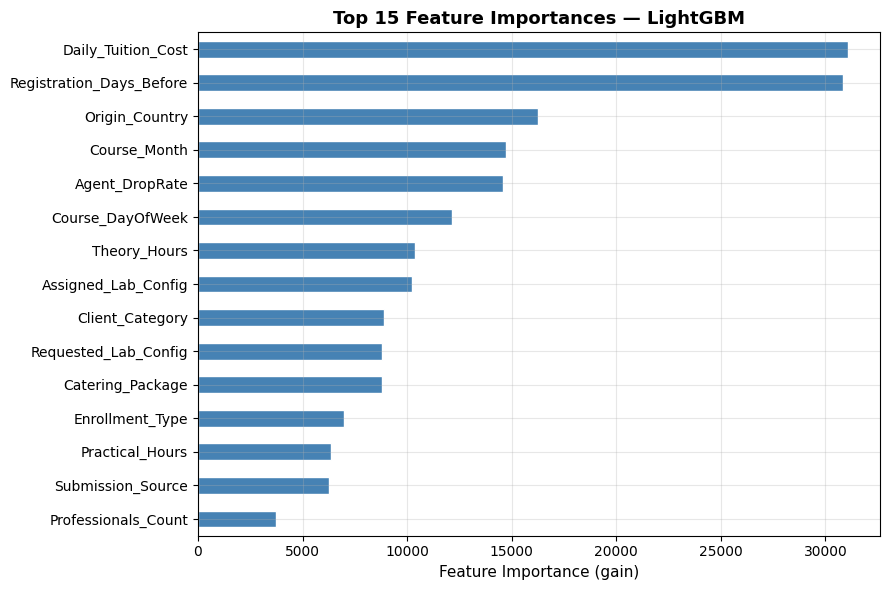

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


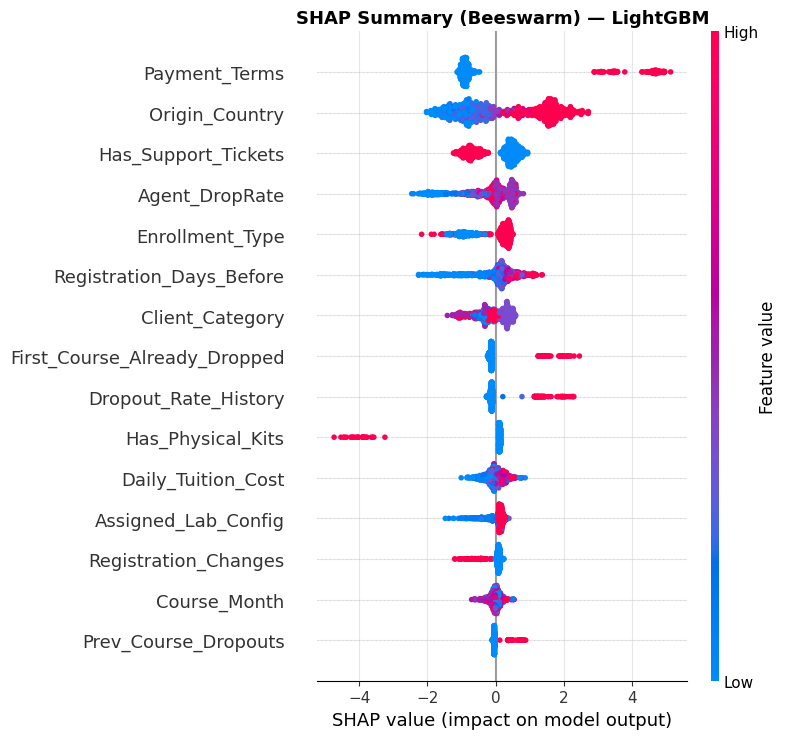

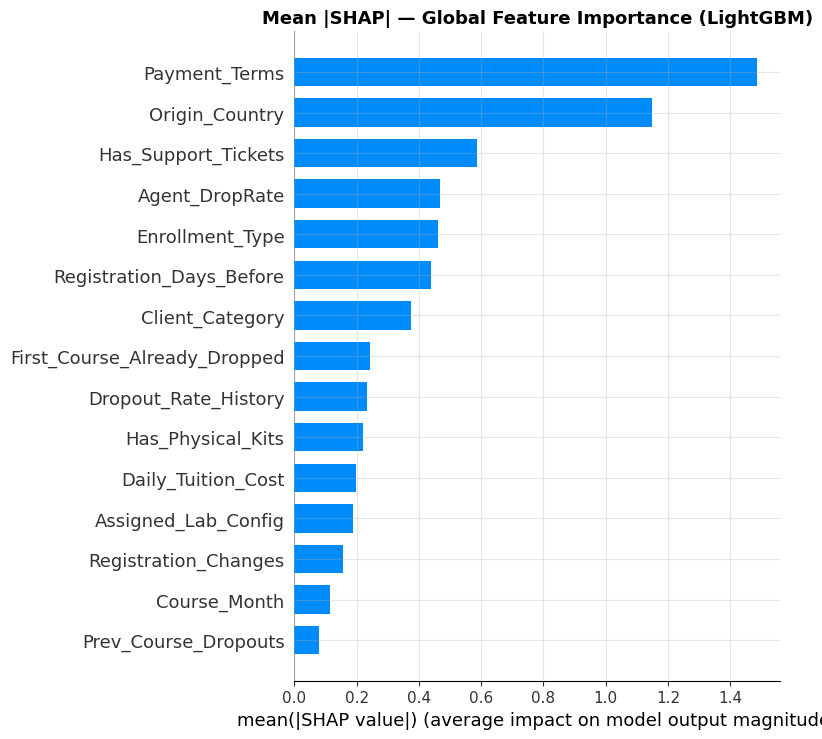


Top features driving uncertainty (mean |SHAP| within the 563 rows in the 0.4-0.6 zone):
Payment_Terms               0.880
Origin_Country              0.828
Has_Support_Tickets         0.665
Agent_DropRate              0.411
Enrollment_Type             0.391
Client_Category             0.331
Registration_Days_Before    0.327
Daily_Tuition_Cost          0.187
Assigned_Lab_Config         0.174
Registration_Changes        0.148
dtype: float64


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
best_model_name = max(all_results, key=lambda k: all_results[k] if k != 'FINAL ENSEMBLE' else -1)
best_model = models[best_model_name]

# For pipeline-wrapped models, unwrap the classifier
if hasattr(best_model, 'named_steps') and 'clf' in best_model.named_steps:
    inner_model = best_model.named_steps['clf']
else:
    inner_model = best_model

print(f"Interpretive proxy model: {best_model_name} (test AUC = {all_results[best_model_name]:.4f})")

tree_models = {'XGBoost', 'LightGBM', 'RandomForest'}
if best_model_name in tree_models:
    importances = pd.Series(inner_model.feature_importances_, index=X_train.columns)
    importance_label = 'Feature Importance (gain)'
else:
    importances = pd.Series(np.abs(inner_model.coef_[0]), index=X_train.columns)
    importance_label = 'Feature Importance (|coef|)'

top_importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_importances[::-1].plot(kind='barh', ax=ax, color=MAIN_COLOR, edgecolor='white')
ax.set_title(f'Top 15 Feature Importances — {best_model_name}')
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.show()


if best_model_name in tree_models:
    X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
    plt.title(f'SHAP Summary (Beeswarm) — {best_model_name}')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
    plt.title(f'Mean |SHAP| — Global Feature Importance ({best_model_name})')
    plt.tight_layout()
    plt.show()

    X_uncertain = X_test.loc[uncertain_mask]
    shap_values_uncertain = explainer.shap_values(X_uncertain)
    if isinstance(shap_values_uncertain, list):
        shap_values_uncertain = shap_values_uncertain[1]

    mean_abs_shap_uncertain = pd.Series(
        np.abs(shap_values_uncertain).mean(axis=0), index=X_uncertain.columns
    ).sort_values(ascending=False).head(10)

    print(f"\nTop features driving uncertainty "
          f"(mean |SHAP| within the {n_uncertain} rows in the 0.4-0.6 zone):")
    print(mean_abs_shap_uncertain.round(3))
else:
    print(f"\nSHAP analysis skipped: {best_model_name} is not a tree-based model.")

**Conclusions:**

**Global feature importance:**

1. **According to Gain**, `Daily_Tuition_Cost` and `Registration_Days_Before` dominate,
   followed by `Origin_Country` and `Agent_DropRate`. The features encoded via Drop-Rate
   Encoding (`Origin_Country`, `Assigned_Lab_Config`, `Catering_Package` and others) appear
   consistently in the top ranks — direct evidence that the unified encoding decision from
   Section 3.12 produced high-quality features. The calendar-based features
   (`Course_Month`, `Course_DayOfWeek`), built based on Section 2.5.9, also appear in the
   top 10.

2. **However, the binary features engineered in Section 3 (`Has_Physical_Kits`,
   `First_Course_Already_Dropped`, `Has_Support_Tickets` and others) do not appear at all in
   the Gain ranking.** We suspect this reflects the well-known bias where binary features
   have only one split opportunity per tree, systematically underrepresenting them.

3. **SHAP tells a very different story for those same features.** According to SHAP,
   `Payment_Terms` is the single most influential feature by a large margin (mean|SHAP| =
   1.85, ~50% higher than the next feature). The Beeswarm reveals that high values push
   toward cancellation (up to +6 in log-odds) and low values push in the opposite
   direction. `Origin_Country` ranks second with a wide bi-directional influence —
   validating the unified encoding decision empirically.

4. **`First_Course_Already_Dropped` pushes strongly toward cancellation when its value is
   1**, matching precisely the 99.8% cancellation rule discovered in the GMM deep-dive.
   `Has_Physical_Kits` shows the strongest *protective* effect in the data — when its value
   is 1 it pushes toward non-cancellation with dramatic magnitude (SHAP values reaching -5),
   consistent with the 0% cancellation rate observed in Section 2.5.3. This matches
   business intuition: engagement indicators push toward retention, while early risk
   indicators push toward cancellation.

**Uncertain-zone analysis:**

5. **The same features that dominate the model overall also dominate its uncertainty — but
   weakened.** `Payment_Terms` (0.880) and `Origin_Country` (0.828) remain the top two
   drivers, but at roughly half the magnitude they carry in the global SHAP importance
   above. This is exactly what a well-calibrated uncertain zone should look like: the
   strongest features become inconclusive, not absent.

6. **`Has_Support_Tickets` (0.665) is disproportionately important in this uncertain
   region** — well above its typical rank in the global ranking. This is
   domain-meaningful: a support ticket before the course can signal two opposite things —
   active engagement (predicts staying) or early friction (predicts dropping). The model
   can lock onto that signal only when other features are also indicative, so it becomes a
   source of hesitation when the surrounding context is ambiguous. This is exactly the
   kind of case where a business intervention (a proactive follow-up call) could add
   value beyond the model's automated prediction.

# 6. Deployment — Predictions on the Unlabeled Test Set

**deployment mode** — simulating what would actually happen if the model were deployed at
Nova Academy: a new file of registrations arrives without labels, and we need to produce a
cancellation probability for every row.

Two new challenges appear that did not exist in Sections 2–5:

1. **Every feature must be reproducible on new data.** All the imputation values, encoding maps,
   the GMM clustering, the binary conversions — every derived parameter learned from training
   must be *applied* to the new file exactly as it was applied to the internal test set,
   without re-learning anything from the new labels (there are no labels to learn from).

2. **The final model should be retrained on 100% of the labeled data.** The 20% internal test
   set was held out to give an honest evaluation in Section 5. Now that the evaluation is
   complete, there is no reason to leave those rows unused — a stronger model can be built by
   training on the full labeled dataset before scoring the real test set.

## 6.1 Preprocessing Function for the Unlabeled Test Set

This function is the deployment-mode equivalent of everything Sections 3.1 through 3.12 did to
the training data — packaged into a single reusable function that applies (never re-learns) all
the pipeline steps to any new dataframe. It expects a raw dataframe in the same schema as
`Train_Data.csv` and returns two objects: the client IDs (needed for the submission file) and
the fully-encoded feature matrix, aligned to the exact columns the models were trained on.

Key deployment-mode differences from Section 3:

- **No outlier removal.** Every client in the real test set must receive a prediction, even if
  their values look extreme. Removing rows here would leave some clients with no prediction.
- **All train-learned parameters are used as-is.** The imputation medians and modes, the
  smoothed encoding maps for high-cardinality features (`Company_ID`, `Agent_ID`, and the seven
  categoricals), the fitted GMM and its scaler, the `high_risk_cluster_id`, and the final
  column ordering (`TRAIN_COLUMNS`) — all learned once during training, all applied here without
  modification.
- **Unseen categories are handled gracefully.** If a new file contains a category never seen
  during training (e.g., a new country), the smoothed encoding falls back to the global mean —
  a safe default that neither over- nor under-estimates risk.

In [ ]:
def preprocess_real_test(df):
    # Apply the full training-time pipeline to an unlabeled dataframe
    # Uses only parameters learned during training — nothing is refitted here
    df = df.copy()

    # Step 1: Text standardization + date parsing (same as training)
    for col in df.select_dtypes(include=['object']).columns:
        if col == 'Course_Start_Date':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        else:
            df[col] = df[col].apply(clean_text)

    # NOTE: No outlier removal — every client must receive a prediction.

    # Step 2: Drop non-informative columns (Section 2.5.5 decision)
    for col in ['Lanyard_Color', 'Welcome_Gift_Type']:
        if col in df.columns:
            df = df.drop(columns=col)

    # Step 3: Company_ID & Agent_ID features (leakage-safe smoothed maps)
    df['Has_Company_ID'] = df['Company_ID'].notna().astype(int)
    df['Company_DropRate'] = df['Company_ID'].map(company_full_map).fillna(company_gm)
    df['Has_Agent'] = df['Agent_ID'].notna().astype(int)
    df['Agent_DropRate'] = df['Agent_ID'].map(agent_full_map).fillna(agent_gm)
    df = df.drop(columns=['Company_ID', 'Agent_ID'])

    # Step 4: Impute missing values with train-learned medians / modes
    for col in numerical_to_impute:
        df[col] = df[col].fillna(train_medians[col])
    for col in cat_to_fill:
        df[col] = df[col].fillna(train_modes[col])

    # Step 5: Calendar features from Course_Start_Date
    d = pd.to_datetime(df['Course_Start_Date'])
    df['Course_DayOfWeek'] = d.dt.dayofweek
    df['Course_Month'] = d.dt.month
    df['Is_Holiday_Period'] = [_falls_on_holiday(c, dt) for c, dt in zip(df['Origin_Country'], d)]

    # Step 6: Dropout_Rate_History (Section 3.10)
    df['Dropout_Rate_History'] = (
        df['Prev_Course_Dropouts'] / (df['Prev_Course_Attended'] + 1)
    ).clip(upper=2.0)

    # Step 7: GMM-based features (Section 3.3)
    df = add_dropout_features(df)

    # Step 8: Binary conversion of zero-heavy features (Section 3.11)
    binary_conversions = {
        'Students_Count':              'Has_Students',
        'Physical_Course_Kits':        'Has_Physical_Kits',
        'Observers_Count':             'Has_Observers',
        'Prev_Course_Attended':        'Has_Prev_Attendance',
        'Pre_Course_Supports_Tickets': 'Has_Support_Tickets',
    }
    for src_col, new_col in binary_conversions.items():
        df[new_col] = (df[src_col] > 0).astype(int)
    df = df.drop(columns=list(binary_conversions.keys()))

    # Step 9: Separate Client_ID + drop raw date
    client_ids = df['Client_ID']
    X = df.drop(columns=['Client_ID', 'Course_Start_Date'])

    # Step 10: Apply train-learned target encoding to all 8 categoricals
    for col, (full_map, gm) in encoding_maps.items():
        X[col] = X[col].map(full_map).fillna(gm)

    # Step 11: Safety net + align to the exact training columns
    remaining_obj = X.select_dtypes(include=['object']).columns.tolist()
    if remaining_obj:
        X = pd.get_dummies(X, columns=remaining_obj)
    X = X.reindex(columns=TRAIN_COLUMNS, fill_value=0)

    return client_ids, X

## 6.2 Retrain All Models on the Full Labeled Dataset

For deployment we retrain everything on the full labeled dataset (train + internal test),
because there is no longer a reason to hold out those 20% — the evaluation in Section 5 is
already complete. All train-learned parameters are recomputed from the full data
(smoothed maps, imputation medians and modes, GMM, target encodings), the base models are
refit, and both ensemble strategies (stacking meta-model and blending weights) are rebuilt
with fresh out-of-fold predictions on the full data.

This means the deployed model is trained on 25% more data than the model evaluated in Section 5
— a small but real improvement that translates directly into more robust predictions on the
unlabeled test set.

In [ ]:

# Rebuild the full labeled dataset, re-fit all learned
# parameters, and retrain the base models + ensemble


# Step 1: Reload the full labeled dataset from scratch
full_df = pd.read_csv("Train_Data.csv")
for col in full_df.select_dtypes(include=['object']).columns:
    if col == 'Course_Start_Date':
        full_df[col] = pd.to_datetime(full_df[col], errors='coerce')
    else:
        full_df[col] = full_df[col].apply(clean_text)

# Apply the same outlier rules (Section 3.1) — consistent with training
full_df = full_df[full_df['Practical_Hours'].isna() | full_df['Practical_Hours'].between(0, 16)]
full_df = full_df[full_df['Students_Count'].isna() | (full_df['Students_Count'] <= 3)]
full_df = full_df[full_df['Daily_Tuition_Cost'].isna() | (full_df['Daily_Tuition_Cost'] < 500)]

y_full = full_df['Dropped_Course']
global_drop_rate = y_full.mean()
full_df = full_df.drop(columns=['Lanyard_Color', 'Welcome_Gift_Type'])

# Step 2: Recompute Company/Agent smoothed maps
full_df['Has_Company_ID'] = full_df['Company_ID'].notna().astype(int)
company_full_map, company_gm = _fit_smoothed_map(full_df['Company_ID'], y_full, m=20)
full_df['Company_DropRate'] = full_df['Company_ID'].map(company_full_map).fillna(company_gm)
full_df['Has_Agent'] = full_df['Agent_ID'].notna().astype(int)
agent_full_map, agent_gm = _fit_smoothed_map(full_df['Agent_ID'], y_full, m=20)
full_df['Agent_DropRate'] = full_df['Agent_ID'].map(agent_full_map).fillna(agent_gm)
full_df = full_df.drop(columns=['Company_ID', 'Agent_ID'])

# Step 3: Recompute imputation values
train_medians = {c: full_df[c].median() for c in numerical_to_impute}
for c in numerical_to_impute:
    full_df[c] = full_df[c].fillna(train_medians[c])
train_modes = {c: full_df[c].mode()[0] for c in cat_to_fill}
for c in cat_to_fill:
    full_df[c] = full_df[c].fillna(train_modes[c])

# Step 4: Calendar + Dropout_Rate_History
_d = pd.to_datetime(full_df['Course_Start_Date'])
full_df['Course_DayOfWeek'] = _d.dt.dayofweek
full_df['Course_Month'] = _d.dt.month
full_df['Is_Holiday_Period'] = [_falls_on_holiday(c, dt) for c, dt in zip(full_df['Origin_Country'], _d)]
full_df = full_df.drop(columns=['Course_Start_Date'])
full_df['Dropout_Rate_History'] = (
    full_df['Prev_Course_Dropouts'] / (full_df['Prev_Course_Attended'] + 1)).clip(upper=2.0)

# Step 5: Refit the GMM on full data (override the train-only fit)
gmm_impute_medians = full_df[gmm_cluster_cols].median()
gmm_fit_data = full_df[gmm_cluster_cols].fillna(gmm_impute_medians).copy()
for c in gmm_skewed_cols:
    gmm_fit_data[c] = np.log1p(gmm_fit_data[c])
gmm_scaler = StandardScaler().fit(gmm_fit_data)
gmm_final = GaussianMixture(
    n_components=6, covariance_type='diag', random_state=42, n_init=5, reg_covar=1e-4
).fit(gmm_scaler.transform(gmm_fit_data))
full_df['gmm_cluster_tmp'] = gmm_final.predict(gmm_scaler.transform(gmm_fit_data))
high_risk_cluster_id = full_df.groupby('gmm_cluster_tmp')['Dropped_Course'].mean().idxmax()
full_df = add_dropout_features(full_df).drop(columns=['gmm_cluster_tmp'])

# Step 6: Binary conversion of zero-heavy count features
binary_conversions = {
    'Students_Count':              'Has_Students',
    'Physical_Course_Kits':        'Has_Physical_Kits',
    'Observers_Count':             'Has_Observers',
    'Prev_Course_Attended':        'Has_Prev_Attendance',
    'Pre_Course_Supports_Tickets': 'Has_Support_Tickets',
}
for src_col, new_col in binary_conversions.items():
    full_df[new_col] = (full_df[src_col] > 0).astype(int)
full_df = full_df.drop(columns=list(binary_conversions.keys()))

# Step 7: Refit the target encoding maps on full data
X_full = full_df.drop(columns=['Dropped_Course', 'Client_ID'])
for col in target_enc_cols:
    full_map, gm = _fit_smoothed_map(X_full[col], y_full, m=20)
    X_full[col] = X_full[col].map(full_map).fillna(gm)
    encoding_maps[col] = (full_map, gm)

# Step 8: Align to the training column ordering
_rem = X_full.select_dtypes(include=['object']).columns.tolist()
if _rem:
    X_full = pd.get_dummies(X_full, columns=_rem)
X_full = X_full.reindex(columns=TRAIN_COLUMNS, fill_value=0)
assert X_full.isna().sum().sum() == 0, "NaNs in full training data!"
print(f"Final training set (all labeled data): {X_full.shape}")

# Step 9: Refit base models on full data
final_models = {name: clone(model).fit(X_full, y_full) for name, model in models.items()}

# Step 10: Rebuild OOF predictions on full data (for the ensemble)
oof_full = pd.DataFrame(index=X_full.index)
skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    oof_col = np.zeros(len(X_full))
    for tr_idx, val_idx in skf_final.split(X_full, y_full):
        mdl = clone(model).fit(X_full.iloc[tr_idx], y_full.iloc[tr_idx])
        oof_col[val_idx] = mdl.predict_proba(X_full.iloc[val_idx])[:, 1]
    oof_full[name] = oof_col

# Step 11: Refit both ensemble strategies on the new OOF
final_meta_model = LogisticRegression(max_iter=2000, random_state=42).fit(oof_full, y_full)

def _neg_auc_full(weights):
    weights = np.abs(weights)
    if weights.sum() == 0:
        return 0
    weights = weights / weights.sum()
    return -roc_auc_score(y_full, (oof_full.values * weights).sum(axis=1))

_res_full = minimize(_neg_auc_full, np.ones(oof_full.shape[1]) / oof_full.shape[1],
                      method='Nelder-Mead', options={'maxiter': 2000, 'xatol': 1e-5})
blend_weights = np.abs(_res_full.x) / np.abs(_res_full.x).sum()

print(f"\nDeployment strategy: {final_strategy.upper()}")
print(f"Base models retrained on {len(X_full)} rows (was {len(X_train)} in training).")

Final training set (all labeled data): (63291, 32)

Deployment strategy: STACKING
Base models retrained on 63291 rows (was 50633 in training).


## 6.3 Generate Predictions and Write the Submission File

The unlabeled test file is loaded, passed through `preprocess_real_test` (which applies every
step of the pipeline using the parameters just refit in Section 6.3), and scored by the
final base models. The strategy chosen in Section 4.4 — `stacking` or `blending` — is applied
to combine the base predictions into a final cancellation probability for each client. The
result is written to `Group_03_Submission.csv` with two columns: `Client_ID` and
`Drop_Probability`.

In [ ]:
# Load the unlabeled test set
real_test = pd.read_csv("Test_Data_No_Target.csv")
print(f"Loaded test set: {real_test.shape}")

# Preprocess through the exact same pipeline used in training
client_ids, X_real = preprocess_real_test(real_test)
print(f"Processed test features: {X_real.shape}")
assert list(X_real.columns) == TRAIN_COLUMNS, "Column mismatch with train!"
assert X_real.isna().sum().sum() == 0, "NaNs remain in processed test!"

# Score with each retrained base model
base_test_preds = pd.DataFrame(index=X_real.index)
for name, model in final_models.items():
    base_test_preds[name] = model.predict_proba(X_real)[:, 1]

# Combine base predictions using the strategy chosen in Section 4.4
if final_strategy == 'blending':
    real_probs = (base_test_preds.values * blend_weights).sum(axis=1)
else:
    real_probs = final_meta_model.predict_proba(base_test_preds)[:, 1]

# Build and save the submission file
submission = pd.DataFrame({
    'Client_ID': client_ids.values,
    'Drop_Probability': real_probs,
})
submission.to_csv("Group_03_Submission.csv", index=False)

print(f"\nSubmission saved: {submission.shape}")
print(f"Probability range: {real_probs.min():.3f} — {real_probs.max():.3f}")
submission.head()

Loaded test set: (15866, 28)
Processed test features: (15866, 32)

Submission saved: (15866, 2)
Probability range: 0.025 — 0.982


,Client_ID,Drop_Probability
0,62246,0.060490
1,43031,0.982334
2,26571,0.049804
3,77694,0.982334
4,22185,0.133023


In [ ]:
from google.colab import files
files.download("Group_03_Submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>